<a href="https://colab.research.google.com/github/oth0n-as/enem2022-etl-pipeline/blob/main/projeto_datamajor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="text-align:right">
    <a href="https://www.iesb.br/home/" target="_blank">
    <img src="https://www.iesb.br/content/themes/iesb-chleba-themosis/assets/imagens/logo.png" />
    </a>
</p>

---

#  Projeto data major — Pipeline ETL Completo

| | |
|---|---|
| **Instituição** | Centro Universitário IESB |
| **Curso** | Ciência da Computação |
| **Disciplina** | Tópicos de Banco de Dados |
| **Semestre** | 2026 |
| **Docente** | Prof. Rodrigo Gonçalves |

---

##  Tema

> **Análise do impacto de fatores socioeconômicos e demográficos na nota final dos participantes do ENEM**

---

##  Equipe e Responsabilidades

| Integrante | Responsabilidade | Etapa |
|---|---|---|
| Othon Flávio Alves de Sales | Coleta automatizada dos dados | **Extract** |
| Mariana Paiva de Souza Moreira | Limpeza, padronização e preparação | **Transform** |
|Nikolas Silva de Sousa | Modelagem e armazenamento | **Load** |
| Matheus de Paula Machado Turturro | Técnica analítica e métricas | **Mineração** |

---

##  Dataset

| | |
|---|---|
| **Fonte** | INEP — Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira |
| **Dataset** | Microdados do ENEM 2022 |
| **Acesso** | [gov.br/inep — Dados Abertos](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem) |
| **Formato original** | CSV · separador `;` · encoding `latin-1` |
| **Formato tratado** | Parquet · compressão `snappy` |
| **Volume original** | ~1 GB (comprimido em ZIP) |
| **Colunas selecionadas** | 29 analíticas (de 136 disponíveis) |

---

##  Visão Geral do Pipeline

```
┌─────────────────────────────────────────────────────────────────┐
│                     PIPELINE ETL — data major                   │
├──────────────┬──────────────────┬──────────────┬────────────────┤
│   EXTRACT    │    TRANSFORM     │     LOAD     │   MINERAÇÃO    │
│              │                  |              |                |
├──────────────┼──────────────────┼──────────────┼────────────────┤
│ • Download   │ • Seleção cols   │ • PySpark    │ • Regressão    │
│   ZIP INEP   │ • Remoção trein. │ • Parquet    │   Linear Múltipla│
│ • Hash SHA256│ • Var. alvo      │   particion. │ • Métricas     │
│ • Extração   │ • Ausentes       │ • Compressão │ • Interpretação│
│ • raw/       │ • Tipos          │   snappy     │                │
│ • Metadados  │ • Feature eng.   │ • Metadados  │                │
│              │ • Parquet final  │              │                │
├──────────────┼──────────────────┼──────────────┼────────────────┤
│✅ Concluído  | ✅ Concluído    │✅ Concluído  │  ✅ Concluído │
└──────────────┴──────────────────┴──────────────┴────────────────┘
```

**Ciclo de dados:**
`Coleta` → `Tratamento` → `Armazenamento` → `Modelagem` → `Análise` → `Interpretação`

---

##  Estrutura de Pastas

```
data_major/
├── raw/                        ← dados brutos, nunca modificados
│   ├── microdados_enem_2022.zip
│   └── microdados_enem_2022/   ← conteúdo extraído do ZIP
├── processed/                  ← saídas do Transform
│   ├── enem_2022_tratado.parquet
│   └── analise_exploratoria.png
├── load/                        ← saídas do Load
│   └── enem_2022/               ← Parquet particionado
├── extract_metadata.json       ← rastreabilidade da coleta
├── transform_metadata.json     ← rastreabilidade do tratamento
└── load_metadata.json           ← rastreabilidade do armazenamento
```

---


---

#  Etapa Extract

**Responsável:** Othon Flávio Alves de Sales

Esta etapa é responsável exclusivamente pela **coleta automatizada** dos dados brutos do ENEM 2022 diretamente da fonte oficial (INEP).

A etapa de Extract tem uma responsabilidade bem definida dentro do pipeline ETL: obter os dados da fonte e armazená-los intactos na pasta `raw/`, **sem realizar nenhum tipo de tratamento, filtragem ou transformação**. Qualquer modificação nos dados é responsabilidade da etapa seguinte (Transform).

**O que será feito aqui:**
- Montar o Google Drive para persistência dos arquivos;
- Fazer o download automatizado do ZIP oficial do INEP;
- Verificar a integridade do arquivo baixado (hash SHA-256);
- Extrair o conteúdo do ZIP para a pasta `raw/`;
- Registrar os metadados da coleta para rastreabilidade.

---


In [ ]:

# ============================================================
# Etapa 1 - Instalação das bibliotecas necessárias
#
# Algumas bibliotecas podem não estar disponíveis por padrão
# no Google Colab. Instalamos aqui o que for necessário.
#
# - requests: realiza requisições HTTP para o download.
# - tqdm: exibe a barra de progresso durante o download.
# ============================================================
!pip install requests tqdm

In [ ]:
import os
import shutil
from google.colab import drive

print("🔄 Corrigindo bug de montagem do Colab...")

# 1. Força o desmonte via comando Linux caso esteja travado em segundo plano
!umount -l /content/drive 2>/dev/null

# 2. Se a pasta local existir mas não estiver funcionando, limpa os resíduos fantasmas
if os.path.exists('/content/drive') and not os.path.exists('/content/drive/MyDrive'):
    try:
        shutil.rmtree('/content/drive')
        print("🧹 Resíduos de montagens antigas limpos com sucesso.")
    except Exception as e:
        print(f"⚠️ Aviso: Não foi possível apagar a pasta temporária ({e}), tentando prosseguir...")

# 3. Verifica se já está montado. Se não estiver, monta do zero de forma limpa
if not os.path.exists('/content/drive/MyDrive'):
    print("🔌 Conectando ao Google Drive...")
    drive.mount('/content/drive', force_remount=True)
else:
    print("✅ O seu Google Drive JÁ ESTÁ conectado e pronto para uso!")

🔄 Corrigindo bug de montagem do Colab...
🧹 Resíduos de montagens antigas limpos com sucesso.
🔌 Conectando ao Google Drive...
Mounted at /content/drive


In [ ]:
# ============================================================
# Etapa 3 - Importação das bibliotecas
#
# Importamos as bibliotecas que serão usadas ao longo do script.
#
# - os: manipulação de caminhos e diretórios do sistema.
# - requests: realiza requisições HTTP para baixar o arquivo.
# - zipfile: extrai arquivos .zip após o download.
# - tqdm: exibe uma barra de progresso durante o download.
# - hashlib: calcula o hash do arquivo para verificação de integridade.
# - json: salva os metadados da coleta em formato estruturado.
# - datetime: registra a data e hora da coleta.
# ============================================================

import os
import requests
import zipfile
from tqdm import tqdm
import hashlib
import json
from datetime import datetime

print("✅ Bibliotecas importadas com sucesso.")

✅ Bibliotecas importadas com sucesso.


In [ ]:
# ============================================================
# Etapa 4 - Definição das constantes do projeto
#
# Centralizamos aqui todas as configurações da etapa de Extract:
# URL de download, nome do arquivo e pastas de destino.
#
# Manter tudo aqui facilita a manutenção: se a URL ou o caminho
# mudar, basta alterar neste único bloco.
# ============================================================

# URL oficial dos microdados do ENEM 2022 (INEP)
URL_DOWNLOAD = "https://download.inep.gov.br/microdados/microdados_enem_2022.zip"

# Nome do arquivo ZIP que será salvo localmente
NOME_ARQUIVO_ZIP = "microdados_enem_2022.zip"

# Pasta raiz do projeto dentro do Google Drive.
# Todos os arquivos gerados serão salvos aqui, garantindo
# que não se percam ao encerrar a sessão do Colab.
PASTA_PROJETO = "/content/drive/MyDrive/data_major"

# Pasta onde os dados brutos serão armazenados (convenção ETL).
# Os dados originais nunca são modificados após salvos aqui.
PASTA_RAW = os.path.join(PASTA_PROJETO, "raw")

# Arquivo de metadados da coleta (rastreabilidade)
ARQUIVO_METADADOS = os.path.join(PASTA_PROJETO, "extract_metadata.json")

print(f" Pasta do projeto     : {PASTA_PROJETO}")
print(f" Pasta dos dados brutos: {PASTA_RAW}")


 Pasta do projeto     : /content/drive/MyDrive/data_major
 Pasta dos dados brutos: /content/drive/MyDrive/data_major/raw


In [ ]:
# ============================================================
# Etapa 5 - Criação da estrutura de pastas
#
# Criamos a pasta raw/ para armazenar os dados brutos.
# A separação entre raw/ e as etapas seguintes (transform, load)
# é uma boa prática de engenharia de dados: os dados originais
# nunca são modificados, garantindo rastreabilidade total.
# ============================================================

os.makedirs(PASTA_RAW, exist_ok=True)

print(f"\n✅ Estrutura de pastas criada:")
print(f"   {PASTA_PROJETO}/")
print(f"   └── raw/")


✅ Estrutura de pastas criada:
   /content/drive/MyDrive/data_major/
   └── raw/


In [ ]:
# ============================================================
# Etapa 6 - Download automatizado do dataset
#
# Utilizamos a biblioteca requests para realizar o download
# diretamente da URL oficial do INEP.
#
# O parâmetro stream=True é importante: ele permite baixar o
# arquivo em partes (chunks), sem precisar carregar tudo na
# memória de uma vez — essencial para arquivos grandes como
# os microdados do ENEM (~1 GB comprimido).
#
# A barra de progresso (tqdm) exibe o andamento em tempo real.
#
# Caso o arquivo já exista no Drive, o download é ignorado
# para evitar retrabalho desnecessário.
# ============================================================

caminho_zip = os.path.join(PASTA_RAW, NOME_ARQUIVO_ZIP)

def realizar_download(url, destino):
    """
    Realiza o download de um arquivo a partir de uma URL,
    salvando no caminho de destino informado.
    Exibe barra de progresso durante o processo.
    """
    print(f"\n Iniciando download...")
    print(f"   Fonte  : {url}")
    print(f"   Destino: {destino}")

    resposta = requests.get(url, stream=True, verify=False, timeout=120)
    resposta.raise_for_status()  # Lança erro se o status HTTP não for 200

    tamanho_total = int(resposta.headers.get("content-length", 0))

    with open(destino, "wb") as arquivo, tqdm(
        desc="   Baixando",
        total=tamanho_total,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
    ) as barra:
        for chunk in resposta.iter_content(chunk_size=8192):
            arquivo.write(chunk)
            barra.update(len(chunk))

    tamanho_real = os.path.getsize(destino)
    print(f"\n✅ Download concluído.")
    print(f"   Tamanho do arquivo: {tamanho_real / (1024**2):.2f} MB")
    return tamanho_real


if not os.path.exists(caminho_zip):
    tamanho_zip = realizar_download(URL_DOWNLOAD, caminho_zip)
else:
    tamanho_zip = os.path.getsize(caminho_zip)
    print(f"\n  Arquivo ZIP já existe no Drive ({tamanho_zip / (1024**2):.2f} MB). Download ignorado.")


  Arquivo ZIP já existe no Drive (591.99 MB). Download ignorado.


In [ ]:
import requests
from tqdm import tqdm
import os

# Tentativa de download robusto com User-Agent
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"}

def download_robusto(url, destino):
    print(f"Tentando download robusto: {url}")
    # Remove o arquivo corrompido anterior se existir
    if os.path.exists(destino):
        os.remove(destino)

    try:
        with requests.get(url, stream=True, headers=headers, verify=False, timeout=300) as r:
            r.raise_for_status()
            total_size = int(r.headers.get('content-length', 0))
            with open(destino, 'wb') as f, tqdm(
                desc="Baixando",
                total=total_size,
                unit='B',
                unit_scale=True,
                unit_divisor=1024,
            ) as bar:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
                    bar.update(len(chunk))
        print(f"\n✅ Download finalizado: {os.path.getsize(destino) / (1024**2):.2f} MB")
    except Exception as e:
        print(f"\n❌ Erro ao baixar: {e}")

download_robusto(URL_DOWNLOAD, caminho_zip)

Tentando download robusto: https://download.inep.gov.br/microdados/microdados_enem_2022.zip


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'download.inep.gov.br'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Baixando: 100%|██████████| 592M/592M [14:01<00:00, 738kB/s]


✅ Download finalizado: 591.99 MB


In [ ]:
# ============================================================
# Etapa 7 - Verificação de integridade do arquivo
#
# Calculamos o hash SHA-256 do arquivo baixado.
# O hash é uma "impressão digital" do arquivo: se qualquer
# byte tiver sido corrompido durante o download, o hash
# será diferente do esperado.
#
# Registramos este valor nos metadados para garantir que,
# sempre que o pipeline for re-executado, o mesmo arquivo
# original esteja sendo utilizado.
# ============================================================

def calcular_hash_sha256(caminho_arquivo, bloco=65536):
    """
    Calcula o hash SHA-256 de um arquivo sem carregá-lo
    inteiro na memória. Útil para arquivos grandes.
    """
    sha256 = hashlib.sha256()
    with open(caminho_arquivo, "rb") as f:
        for bloco_bytes in iter(lambda: f.read(bloco), b""):
            sha256.update(bloco_bytes)
    return sha256.hexdigest()


print("\n Calculando hash SHA-256 para verificação de integridade...")
hash_zip = calcular_hash_sha256(caminho_zip)
print(f"   SHA-256: {hash_zip}")


 Calculando hash SHA-256 para verificação de integridade...
   SHA-256: 3cb321eb490fc4fd2d021fcd7672f1801a6ec37fdfea24a14369f054dc2d8faf


In [ ]:
# ============================================================
# Etapa 8 - Extração do arquivo ZIP
#
# O INEP disponibiliza os microdados comprimidos em formato .zip.
# Extraímos todo o conteúdo para a pasta raw/, mantendo a
# estrutura de arquivos exatamente como foi distribuída pelo INEP.
#
# O ZIP contém, além do CSV dos microdados, arquivos auxiliares
# como o dicionário de variáveis e o questionário do participante.
# Todos são extraídos e preservados sem nenhuma modificação.
#
# Caso a extração já tenha sido feita anteriormente, esta etapa
# é ignorada para evitar retrabalho.
# ============================================================

pasta_extracao = os.path.join(PASTA_RAW, "microdados_enem_2022")

def extrair_zip(caminho_zip, destino):
    """
    Extrai todo o conteúdo de um arquivo ZIP para a pasta
    de destino, preservando a estrutura original de arquivos.
    """
    print(f"\n Extraindo arquivo ZIP...")
    print(f"   Destino: {destino}")

    with zipfile.ZipFile(caminho_zip, "r") as zip_ref:
        membros = zip_ref.namelist()
        print(f"   Arquivos encontrados no ZIP: {len(membros)}")
        for membro in membros:
            print(f"   - {membro}")
        zip_ref.extractall(destino)

    print(f"\n✅ Extração concluída. Todos os arquivos estão em raw/")
    return membros


if not os.path.exists(pasta_extracao):
    arquivos_extraidos = extrair_zip(caminho_zip, pasta_extracao)
else:
    print(f"\n  Pasta de extração já existe. Extração ignorada.")
    with zipfile.ZipFile(caminho_zip, "r") as zip_ref:
        arquivos_extraidos = zip_ref.namelist()


  Pasta de extração já existe. Extração ignorada.


In [ ]:
# ============================================================
# Etapa 9 - Registro dos metadados da coleta
#
# Registramos todas as informações relevantes sobre esta coleta
# em um arquivo JSON. Isso é fundamental para rastreabilidade:
# qualquer integrante do grupo (ou o professor) poderá saber
# de onde vieram os dados, quando foram coletados, qual o
# hash do arquivo e qual a estrutura original do ZIP.
#
# Este arquivo será consultado pelas etapas de Transform e Load.
# ============================================================

metadados = {
    "projeto": "data major - ENEM 2022",
    "tema": "Análise de fatores associados à não conclusão do ensino médio",
    "etapa": "Extract",
    "responsavel": "Othon Flávio Alves de Sales",
    "data_coleta": datetime.now().isoformat(),
    "fonte": {
        "nome": "INEP - Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira",
        "url": URL_DOWNLOAD,
        "descricao": "Microdados do ENEM 2022 - dados oficiais e de domínio público",
        "formato_original": "CSV com separador ponto-e-vírgula (;) e encoding latin-1 (ISO-8859-1)",
        "licenca": "Dados abertos - Governo Federal do Brasil"
    },
    "arquivo_zip": {
        "nome": NOME_ARQUIVO_ZIP,
        "caminho_no_drive": caminho_zip,
        "tamanho_bytes": tamanho_zip,
        "tamanho_mb": round(tamanho_zip / (1024**2), 2),
        "sha256": hash_zip
    },
    "extracao": {
        "pasta_destino": pasta_extracao,
        "total_arquivos_extraidos": len(arquivos_extraidos),
        "arquivos": arquivos_extraidos
    },
    "observacoes": [
        "Nenhuma transformação, filtragem ou modificação foi aplicada nesta etapa.",
        "Os dados estão armazenados em raw/ exatamente como vieram da fonte oficial.",
        "O tratamento dos dados será realizado na etapa Transform.",
        "O hash SHA-256 pode ser usado para verificar a integridade do arquivo a qualquer momento."
    ]
}

with open(ARQUIVO_METADADOS, "w", encoding="utf-8") as f:
    json.dump(metadados, f, ensure_ascii=False, indent=4)

print(f"\n Metadados da coleta salvos em:")
print(f"   {ARQUIVO_METADADOS}")


 Metadados da coleta salvos em:
   /content/drive/MyDrive/data_major/extract_metadata.json


In [ ]:
# ============================================================
# Etapa 10 - Relatório final da etapa de Extract
#
# Exibimos um resumo do que foi realizado, confirmando que
# todos os artefatos estão prontos para a etapa de Transform.
# ============================================================

print("\n" + "="*70)
print("  RELATÓRIO FINAL — ETAPA EXTRACT")
print("="*70)
print(f"\n  Projeto  : data major — ENEM 2022")
print(f"  Tema     : Fatores de não conclusão do Ensino Médio")
print(f"  Concluído: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
print(f"\n  Artefatos gerados em {PASTA_PROJETO}/:")
print(f"  ├── raw/")
print(f"  │   ├── {NOME_ARQUIVO_ZIP}  ({tamanho_zip / (1024**2):.0f} MB) — ZIP original intacto")
print(f"  │   └── microdados_enem_2022/  — Conteúdo extraído sem modificações")
print(f"  └── extract_metadata.json  — Metadados da coleta")
print(f"\n  Hash SHA-256 (ZIP): {hash_zip[:32]}...")
print(f"  Total de arquivos extraídos: {len(arquivos_extraidos)}")
print(f"\n  ✅ Etapa Extract concluída. Dados brutos prontos para o Transform.")
print("="*70)


  RELATÓRIO FINAL — ETAPA EXTRACT

  Projeto  : data major — ENEM 2022
  Tema     : Fatores de não conclusão do Ensino Médio
  Concluído: 16/06/2026 21:10:08

  Artefatos gerados em /content/drive/MyDrive/data_major/:
  ├── raw/
  │   ├── microdados_enem_2022.zip  (592 MB) — ZIP original intacto
  │   └── microdados_enem_2022/  — Conteúdo extraído sem modificações
  └── extract_metadata.json  — Metadados da coleta

  Hash SHA-256 (ZIP): 3cb321eb490fc4fd2d021fcd7672f180...
  Total de arquivos extraídos: 118

  ✅ Etapa Extract concluída. Dados brutos prontos para o Transform.


---

#  Etapa Transform

**Responsável:** Mariana Paiva de Souza Moreira

Esta etapa recebe os dados brutos da pasta `raw/` e aplica limpeza, padronização e preparação para as etapas seguintes.

**O que será feito aqui:**
- Seleção das 28 colunas analíticas relevantes para o tema;
- Remoção de treineiros e registros sem variável-alvo;
- Criação da variável-alvo `NAO_CONCLUIU_EM`;
- Tratamento de valores ausentes com decisões justificadas;
- Padronização e otimização de tipos de dados;
- Feature engineering (média das notas objetivas);
- Salvamento do dataset tratado em formato Parquet.

---


In [ ]:
# ============================================================
# Etapa 11 - Seleção de colunas e filtragem de registros
#
# SELEÇÃO DE COLUNAS (usecols)
# Em vez de carregar as 136 colunas do ENEM, selecionamos
# apenas as 28 colunas analiticamente relevantes para o tema.
# Isso reduz o consumo de memória em ~80% vs. leitura completa
# e mantém o dataset dentro do volume exigido (30–60 MB).
#
# As colunas foram escolhidas para cobrir exatamente o que
# as etapas de tratamento downstream precisam:
#   - Etapas 13–16: notas, presença, questionário e perfil
#   - Etapa 17: identificador único (duplicatas)
#   - Etapa 18: notas objetivas para MEDIA_OBJETIVAS
#
# FILTRAGEM DE REGISTROS
# Decisão 1: Remover treineiros (IN_TREINEIRO == 1)
#   Treineiros fazem o ENEM apenas para treino, sem situação
#   de conclusão do EM em avaliação. Distorcem a análise.
#   IN_TREINEIRO é lido só para este filtro e depois descartado.
#
# Decisão 2: Remover ausentes em TP_ST_CONCLUSAO
#   Sem a variável-alvo não é possível classificar o
#   candidato. São poucos registros e a remoção é segura.
# ============================================================

import pandas as pd

# --- Identificação básica ---
colunas_interesse = [
    "NU_INSCRICAO",       # Identificador único do participante
    "TP_FAIXA_ETARIA",   # Faixa etária
    "TP_SEXO",           # Sexo
    "TP_COR_RACA",       # Cor/raça autodeclarada
    "TP_ESCOLA",         # Tipo de escola do Ensino Médio
    "TP_ST_CONCLUSAO",   # Situação de conclusão do EM (base da variável-alvo)
    "TP_ESTADO_CIVIL",   # Estado civil
    "TP_ENSINO",         # Tipo de ensino (regular, EJA etc.)
    "SG_UF_PROVA",       # UF da prova - onde o candidato realizou a prova do ENEM
]

# --- Notas por área ---
colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO",
]

# --- Presença nas provas ---
colunas_presenca = [
    "TP_PRESENCA_CN",
    "TP_PRESENCA_CH",
    "TP_PRESENCA_LC",
    "TP_PRESENCA_MT",
]

# --- Questionário socioeconômico ---
# Mantemos todas as colunas que a Etapa 14 já trata,
# garantindo consistência entre leitura e transformação.
colunas_questionario = [
    "Q001",  # Escolaridade do pai
    "Q002",  # Escolaridade da mãe
    "Q003",  # Ocupação do pai
    "Q004",  # Ocupação da mãe
    "Q005",  # Número de pessoas no domicílio
    "Q006",  # Faixa de renda familiar
    "Q007",  # Possui empregada doméstica?
    "Q008",  # Possui banheiro?
    "Q009",  # Possui carro?
    "Q024",  # Acesso à internet em casa
    "Q025",  # Possui computador?
]

# Lista final de colunas analíticas (28 colunas)
colunas_analiticas = (
    colunas_interesse +
    colunas_notas +
    colunas_presenca +
    colunas_questionario
)

# IN_TREINEIRO: lido apenas para o filtro, descartado depois
colunas_utilizadas = colunas_analiticas + ["IN_TREINEIRO"]

# Definir o caminho para o arquivo CSV dos microdados
caminho_microdados = os.path.join(pasta_extracao, "DADOS", "MICRODADOS_ENEM_2022.csv")

print(f"  Colunas analíticas selecionadas: {len(colunas_analiticas)} (de 136 disponíveis)")
print(f"  Colunas lidas no CSV            : {len(colunas_utilizadas)} (+IN_TREINEIRO para filtro)")
print(f"\n  Carregando CSV com leitura seletiva...")

# Leitura seletiva: carrega apenas as colunas necessárias
df_raw = pd.read_csv(
    caminho_microdados,
    sep=";",
    encoding="latin-1",
    usecols=colunas_utilizadas,
    low_memory=False
)

n_inicial = len(df_raw)
df = df_raw.copy()

# Decisão 1: remover treineiros
mask_treineiro = df["IN_TREINEIRO"] == 1
n_treineiros = mask_treineiro.sum()
df = df[~mask_treineiro].copy()
df = df.drop(columns=["IN_TREINEIRO"])  # Descarta após uso
print(f"  Removidos treineiros          : {n_treineiros:>10,} registros")

# Decisão 2: remover linhas sem variável-alvo
mask_sem_alvo = df["TP_ST_CONCLUSAO"].isnull()
n_sem_alvo = mask_sem_alvo.sum()
df = df[~mask_sem_alvo].copy()
print(f"  Removidos sem TP_ST_CONCLUSAO : {n_sem_alvo:>10,} registros")

print(f"\n  Registros antes da filtragem  : {n_inicial:>10,}")
print(f"  Registros após a filtragem    : {len(df):>10,}")
print(f"  Registros removidos (total)   : {n_inicial - len(df):>10,} ({(n_inicial - len(df)) / n_inicial * 100:.2f}%)")
print(f"\n  Colunas no dataset            : {df.shape[1]} analíticas")
print(f"  Memória atual                 : {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")
print("\n✅ Leitura seletiva e filtragem concluídas.")


  Colunas analíticas selecionadas: 29 (de 136 disponíveis)
  Colunas lidas no CSV            : 30 (+IN_TREINEIRO para filtro)

  Carregando CSV com leitura seletiva...
  Removidos treineiros          :    512,732 registros
  Removidos sem TP_ST_CONCLUSAO :          0 registros

  Registros antes da filtragem  :  3,476,105
  Registros após a filtragem    :  2,963,373
  Registros removidos (total)   :    512,732 (14.75%)

  Colunas no dataset            : 29 analíticas
  Memória atual                 : 2105.4 MB

✅ Leitura seletiva e filtragem concluídas.


In [ ]:
# ============================================================
# Etapa 12 - Criação da variável-alvo NAO_CONCLUIU_EM
#
# Criamos uma variável binária derivada de TP_ST_CONCLUSAO.
# Esta será a variável-alvo para a etapa de Mineração.
#
#   NAO_CONCLUIU_EM = 1  →  Candidato NÃO concluiu o EM
#                            (TP_ST_CONCLUSAO == 4)
#   NAO_CONCLUIU_EM = 0  →  Candidato concluiu ou está cursando
#                            (TP_ST_CONCLUSAO ∈ {1, 2, 3})
#
# Mantemos a coluna TP_ST_CONCLUSAO original para referência
# e rastreabilidade — ela não é descartada.
# ============================================================

df["NAO_CONCLUIU_EM"] = (df["TP_ST_CONCLUSAO"] == 4).astype(int)

n_nao_concluiu = df["NAO_CONCLUIU_EM"].sum()
n_concluiu = (df["NAO_CONCLUIU_EM"] == 0).sum()
pct_nao = n_nao_concluiu / len(df) * 100

print("\n  Variável-alvo NAO_CONCLUIU_EM criada:")
print(f"   Não concluiu o EM (1): {n_nao_concluiu:>10,}  ({pct_nao:.2f}%)")
print(f"   Concluiu / cursando (0): {n_concluiu:>9,}  ({100 - pct_nao:.2f}%)")
print(f"\n✅ Coluna NAO_CONCLUIU_EM adicionada ao dataset.")


  Variável-alvo NAO_CONCLUIU_EM criada:
   Não concluiu o EM (1):     12,560  (0.42%)
   Concluiu / cursando (0): 2,950,813  (99.58%)

✅ Coluna NAO_CONCLUIU_EM adicionada ao dataset.


In [ ]:
# ============================================================
# Etapa 13 - Tratamento de valores ausentes nas notas
#
# As colunas NU_NOTA_* possuem NaN para participantes que
# faltaram ao dia correspondente da prova.
#
# Decisão adotada: preencher com 0 (zero).
#
# Justificativa:
#   - Ausência na prova = nota 0 para fins do ENEM (o INEP
#     não imputa nota para ausentes).
#   - Zerar é semanticamente correto: o candidato não obteve
#     pontuação naquela área naquele ano.
#   - Alternativa rejeitada (remover a linha): perderia dados
#     de candidatos que compareceram a pelo menos um dia e
#     têm perfil relevante para a análise.
#   - Alternativa rejeitada (imputar média): introduziria viés,
#     pois ausência é informação, não dado faltante aleatório.
# ============================================================

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

nulos_antes = df[colunas_notas].isnull().sum()

df[colunas_notas] = df[colunas_notas].fillna(0)

print("  Tratamento de ausentes nas notas (preenchidos com 0):")
print("-" * 50)
for col in colunas_notas:
    print(f"   {col:<22} → {nulos_antes[col]:>7,} valores preenchidos")

print("\n✅ Notas ausentes tratadas.")

  Tratamento de ausentes nas notas (preenchidos com 0):
--------------------------------------------------
   NU_NOTA_CN             → 1,029,841 valores preenchidos
   NU_NOTA_CH             → 923,107 valores preenchidos
   NU_NOTA_LC             → 923,107 valores preenchidos
   NU_NOTA_MT             → 1,029,841 valores preenchidos
   NU_NOTA_REDACAO        → 923,107 valores preenchidos

✅ Notas ausentes tratadas.


In [ ]:
# ============================================================
# Etapa 14 - Tratamento de valores ausentes no questionário
#            socioeconômico (Q001 a Q025)
#
# As respostas ao questionário socioeconômico são categóricas
# e podem conter NaN quando o participante não as respondeu.
#
# Decisão adotada: preencher com a moda de cada coluna.
#
# Justificativa:
#   - As variáveis são categóricas ordinais (ex.: faixas de
#     renda, letras A–E). Mediana ou média não fazem sentido.
#   - A moda representa a resposta mais comum, sendo uma
#     estimativa conservadora para dados faltantes que
#     representam menos de 5% do total em cada coluna.
#   - Alternativa rejeitada (remover linhas com NaN no
#     questionário): causaria perda expressiva de dados,
#     especialmente de candidatos do grupo de interesse
#     (não concluintes), que tendem a preencher menos o
#     questionário por perfil socioeconômico mais vulnerável.
# ============================================================

colunas_questionario = ["Q001", "Q002", "Q003", "Q004", "Q005",
                         "Q006", "Q007", "Q008", "Q009", "Q024", "Q025"]

print("  Tratamento de ausentes no questionário socioeconômico (moda):")
print("-" * 60)

for col in colunas_questionario:
    nulos = df[col].isnull().sum()
    if nulos > 0:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
        print(f"   {col} → {nulos:>7,} ausentes preenchidos com moda = '{moda}'")
    else:
        print(f"   {col} → sem ausentes")

print("\n✅ Questionário socioeconômico tratado.")

  Tratamento de ausentes no questionário socioeconômico (moda):
------------------------------------------------------------
   Q001 → sem ausentes
   Q002 → sem ausentes
   Q003 → sem ausentes
   Q004 → sem ausentes
   Q005 → sem ausentes
   Q006 → sem ausentes
   Q007 → sem ausentes
   Q008 → sem ausentes
   Q009 → sem ausentes
   Q024 → sem ausentes
   Q025 → sem ausentes

✅ Questionário socioeconômico tratado.


In [ ]:
# ============================================================
# Etapa 15 - Tratamento de ausentes em variáveis categóricas
#            de perfil (TP_COR_RACA, TP_ESTADO_CIVIL, etc.)
#
# Decisão adotada: criar categoria 'Não informado' (valor 9)
# para variáveis de perfil com baixo percentual de ausentes.
#
# Justificativa:
#   - Criar uma categoria própria para dados ausentes é mais
#     honesto do que imputar um valor existente: preserva a
#     informação de que o dado não foi fornecido.
#   - Para modelos de classificação, o valor 9 será tratado
#     como uma categoria adicional (sem viés de imputação).
#   - Alternativa rejeitada (remover linha): os candidatos
#     que não informam cor/raça ou estado civil têm perfil
#     válido e relevante para o tema.
# ============================================================

colunas_categoricas_perfil = [
    "TP_COR_RACA", "TP_ESTADO_CIVIL", "TP_ESCOLA", "TP_ENSINO"
]

print("  Tratamento de ausentes em variáveis de perfil (categoria 9):")
print("-" * 60)

for col in colunas_categoricas_perfil:
    nulos = df[col].isnull().sum()
    if nulos > 0:
        df[col] = df[col].fillna(9).astype(int)
        print(f"   {col:<25} → {nulos:>7,} ausentes → categoria 9")
    else:
        df[col] = df[col].astype(int)
        print(f"   {col:<25} → sem ausentes")

print("\n✅ Variáveis de perfil tratadas.")

  Tratamento de ausentes em variáveis de perfil (categoria 9):
------------------------------------------------------------
   TP_COR_RACA               → sem ausentes
   TP_ESTADO_CIVIL           → sem ausentes
   TP_ESCOLA                 → sem ausentes
   TP_ENSINO                 → 1,700,629 ausentes → categoria 9

✅ Variáveis de perfil tratadas.


In [ ]:
# ============================================================
# Etapa 16 - Correção e padronização de tipos de dados
#
# Garantimos que cada coluna tenha o tipo mais adequado
# para as etapas seguintes (Load e Mineração).
#
# - Variáveis numéricas de nota: float32 (economiza memória
#   sem perda de precisão para notas do ENEM)
# - Variáveis categóricas codificadas: int8 (valores 0–9)
# - Variáveis binárias: int8
# - Strings (UF, sexo): string (tipo pd.StringDtype)
# ============================================================

# Notas: float32
for col in colunas_notas:
    df[col] = df[col].astype("float32")

# Variáveis categóricas inteiras: int8
colunas_int8 = [
    "TP_ST_CONCLUSAO", "TP_COR_RACA", "TP_FAIXA_ETARIA",
    "TP_ESTADO_CIVIL", "TP_NACIONALIDADE", "TP_ESCOLA", "TP_ENSINO",
    "IN_TREINEIRO", "TP_PRESENCA_CN", "TP_PRESENCA_CH",
    "TP_PRESENCA_LC", "TP_PRESENCA_MT", "NAO_CONCLUIU_EM"
]
for col in colunas_int8:
    if col in df.columns:
        df[col] = df[col].astype("int8")

# Strings
df["SG_UF_PROVA"] = df["SG_UF_PROVA"].astype("string")
df["TP_SEXO"] = df["TP_SEXO"].astype("string")

print("\n  Tipos de dados após padronização:")
print("-" * 50)
print(df.dtypes.to_string())
print(f"\n  Memória após otimização: {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")
print("\n✅ Tipos de dados corrigidos.")


  Tipos de dados após padronização:
--------------------------------------------------
NU_INSCRICAO                int64
TP_FAIXA_ETARIA              int8
TP_SEXO            string[python]
TP_ESTADO_CIVIL              int8
TP_COR_RACA                  int8
TP_ST_CONCLUSAO              int8
TP_ESCOLA                    int8
TP_ENSINO                    int8
SG_UF_PROVA        string[python]
TP_PRESENCA_CN               int8
TP_PRESENCA_CH               int8
TP_PRESENCA_LC               int8
TP_PRESENCA_MT               int8
NU_NOTA_CN                float32
NU_NOTA_CH                float32
NU_NOTA_LC                float32
NU_NOTA_MT                float32
NU_NOTA_REDACAO           float32
Q001                       object
Q002                       object
Q003                       object
Q004                       object
Q005                        int64
Q006                       object
Q007                       object
Q008                       object
Q009                       o

In [ ]:
# ============================================================
# Etapa 17 - Remoção de duplicatas
#
# Verificamos se há inscrições duplicadas no dataset.
# NU_INSCRICAO é identificador único por participante/ano.
#
# Embora seja raro nos microdados do INEP, a verificação
# é necessária para garantir a integridade do dataset
# tratado. Duplicatas poderiam inflar métricas e distorcer
# modelos na etapa de Mineração.
# ============================================================

n_antes = len(df)
duplicatas = df.duplicated(subset=["NU_INSCRICAO"]).sum()

if duplicatas > 0:
    df = df.drop_duplicates(subset=["NU_INSCRICAO"], keep="first")
    print(f"  ⚠️  {duplicatas:,} duplicatas encontradas e removidas.")
else:
    print(f"  ✅ Nenhuma duplicata encontrada. Dataset íntegro.")

print(f"\n   Registros antes: {n_antes:,}")
print(f"   Registros após : {len(df):,}")

  ✅ Nenhuma duplicata encontrada. Dataset íntegro.

   Registros antes: 2,963,373
   Registros após : 2,963,373


In [ ]:
# ============================================================
# Etapa 18 - Criação de variável de nota média
#
# Criamos a variável MEDIA_OBJETIVAS como a média aritmética
# das quatro notas objetivas (CN, CH, LC, MT).
#
# Justificativa:
#   - Condensa o desempenho geral em uma única dimensão,
#     útil para análises exploratórias e como feature
#     adicional na etapa de Mineração.
#   - Complementa as notas individuais (que serão mantidas)
#     sem substituí-las.
# ============================================================

notas_objetivas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
df["MEDIA_OBJETIVAS"] = df[notas_objetivas].mean(axis=1).round(2).astype("float32")

print("  Estatísticas de MEDIA_OBJETIVAS:")
print("-" * 40)
print(df.groupby("NAO_CONCLUIU_EM")["MEDIA_OBJETIVAS"].describe().round(2).to_string())
print("\n✅ Variável MEDIA_OBJETIVAS criada.")

  Estatísticas de MEDIA_OBJETIVAS:
----------------------------------------
                     count    mean     std  min  25%     50%     75%     max
NAO_CONCLUIU_EM                                                             
0                2950813.0  349.54  246.83  0.0  0.0  463.92  538.38  839.80
1                  12560.0  301.18  237.35  0.0  0.0  419.25  507.63  738.62

✅ Variável MEDIA_OBJETIVAS criada.


In [ ]:
# ============================================================
# Etapa 19 - Verificação final de ausentes
#
# Após todos os tratamentos, confirmamos que não restam
# valores ausentes nas colunas críticas para a mineração.
#
# Colunas com ausentes residuais que não foram tratados
# (ex.: CO_MUNICIPIO_PROVA, NU_ANO) são aceitas desde que
# não sejam variáveis usadas diretamente no modelo.
# ============================================================

nulos_pos = df.isnull().sum()
nulos_pos = nulos_pos[nulos_pos > 0]

if len(nulos_pos) == 0:
    print("\n✅ Nenhum valor ausente restante. Dataset completamente tratado.")
else:
    print("\n  Ausentes residuais (verificar se impactam o modelo):")
    print("-" * 50)
    for col, qtd in nulos_pos.items():
        pct = qtd / len(df) * 100
        print(f"   {col:<30} {qtd:>8,}  ({pct:.2f}%)")


✅ Nenhum valor ausente restante. Dataset completamente tratado.


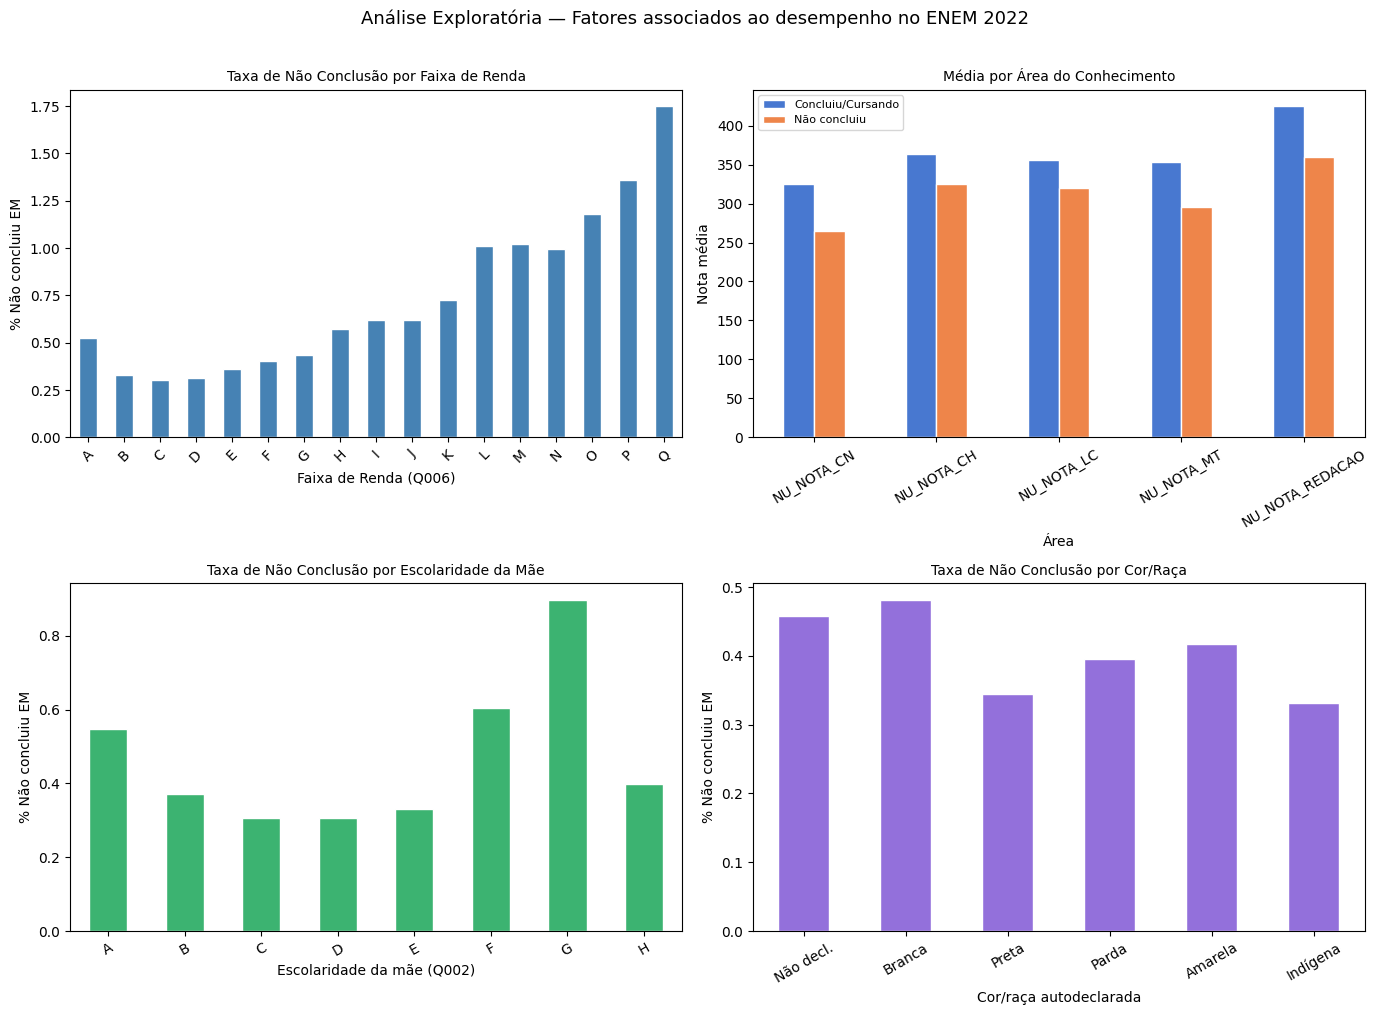

  Gráfico salvo em: /content/drive/MyDrive/data_major/processed/analise_exploratoria.png


In [ ]:
# ============================================================
# Etapa 20 - Análise exploratória pós-transformação
#
# Realizamos visualizações para validar as transformações
# aplicadas e gerar insights iniciais sobre os fatores
# associados ao desempenho educacional no ENEM 2022.
#
# Os 4 gráficos usam exclusivamente as 18 colunas analíticas
# selecionadas, sem depender de colunas descartadas.
# ============================================================

import matplotlib.pyplot as plt

PASTA_PROCESSED = os.path.join(PASTA_PROJETO, "processed")
os.makedirs(PASTA_PROCESSED, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Análise Exploratória — Fatores associados ao desempenho no ENEM 2022",
             fontsize=13, y=1.01)

# --- Gráfico 1: Renda familiar (Q006) vs. não conclusão ---
taxa_renda = df.groupby("Q006")["NAO_CONCLUIU_EM"].mean().sort_index() * 100
taxa_renda.plot(kind="bar", ax=axes[0, 0], color="steelblue", edgecolor="white")
axes[0, 0].set_title("Taxa de Não Conclusão por Faixa de Renda", fontsize=10)
axes[0, 0].set_xlabel("Faixa de Renda (Q006)")
axes[0, 0].set_ylabel("% Não concluiu EM")
axes[0, 0].tick_params(axis="x", rotation=45)

# --- Gráfico 2: Média das notas por situação de conclusão ---
medias = df.groupby("NAO_CONCLUIU_EM")[colunas_notas].mean()
medias.index = ["Concluiu/Cursando", "Não concluiu"]
medias.T.plot(kind="bar", ax=axes[0, 1], color=["#4878d0", "#ee854a"], edgecolor="white")
axes[0, 1].set_title("Média por Área do Conhecimento", fontsize=10)
axes[0, 1].set_xlabel("Área")
axes[0, 1].set_ylabel("Nota média")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].legend(fontsize=8)

# --- Gráfico 3: Escolaridade da mãe (Q002) vs. não conclusão ---
taxa_mae = df.groupby("Q002")["NAO_CONCLUIU_EM"].mean().sort_index() * 100
taxa_mae.plot(kind="bar", ax=axes[1, 0], color="mediumseagreen", edgecolor="white")
axes[1, 0].set_title("Taxa de Não Conclusão por Escolaridade da Mãe", fontsize=10)
axes[1, 0].set_xlabel("Escolaridade da mãe (Q002)")
axes[1, 0].set_ylabel("% Não concluiu EM")
axes[1, 0].tick_params(axis="x", rotation=30)

# --- Gráfico 4: Cor/raça vs. não conclusão ---
mapa_raca = {0: "Não decl.", 1: "Branca", 2: "Preta", 3: "Parda",
             4: "Amarela", 5: "Indígena", 9: "N/I"}
taxa_raca = df.groupby("TP_COR_RACA")["NAO_CONCLUIU_EM"].mean().sort_index() * 100
taxa_raca.index = taxa_raca.index.map(mapa_raca)
taxa_raca.plot(kind="bar", ax=axes[1, 1], color="mediumpurple", edgecolor="white")
axes[1, 1].set_title("Taxa de Não Conclusão por Cor/Raça", fontsize=10)
axes[1, 1].set_xlabel("Cor/raça autodeclarada")
axes[1, 1].set_ylabel("% Não concluiu EM")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
caminho_grafico_eda = os.path.join(PASTA_PROCESSED, "analise_exploratoria.png")
plt.savefig(caminho_grafico_eda, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Gráfico salvo em: {caminho_grafico_eda}")


In [ ]:
# ============================================================
# Etapa 21 - Verificação do volume final do dataset
#
# O projeto exige que o dataset tratado tenha entre 30MB e
# 60MB. Verificamos o tamanho estimado em memória e o volume
# que será gerado ao salvar em CSV.
#
# Caso o volume fique abaixo de 30MB, a etapa Load poderá
# incorporar dados complementares (como o Censo Escolar)
# para atingir o mínimo exigido.
# ============================================================

tamanho_mb_memoria = df.memory_usage(deep=True).sum() / (1024**2)

print(f"\n  Dimensões do dataset tratado:")
print(f"   Linhas  : {len(df):>10,}")
print(f"   Colunas : {df.shape[1]:>10}")
print(f"   Memória : {tamanho_mb_memoria:>9.1f} MB")

# Estimativa do CSV (tipicamente ~2–3x maior que a memória)
estimativa_csv_mb = tamanho_mb_memoria * 2.5
print(f"   CSV estimado: ~{estimativa_csv_mb:.0f} MB")

if estimativa_csv_mb < 30:
    print("\n  ⚠️  Volume estimado abaixo de 30MB.")
    print("     Considere integrar dados adicionais na etapa Load.")
elif estimativa_csv_mb > 60:
    print("\n  ⚠️  Volume estimado acima de 60MB.")
    print("     Considere aplicar uma amostragem estratificada.")
else:
    print("\n  ✅ Volume dentro do intervalo exigido (30–60MB).")


  Dimensões do dataset tratado:
   Linhas  :  2,963,373
   Colunas :         31
   Memória :    1865.2 MB
   CSV estimado: ~4663 MB

  ⚠️  Volume estimado acima de 60MB.
     Considere aplicar uma amostragem estratificada.


In [ ]:
# ============================================================
# Etapa 22 - Salvamento do dataset tratado em Parquet
#
# Salvamos o dataset final em formato Parquet, não CSV.
#
# Por que Parquet?
#   - Formato colunar binário com compressão nativa (snappy).
#   - Reduz o volume em ~90% comparado ao CSV equivalente,
#     mantendo o dataset dentro dos 30–60 MB exigidos.
#   - Preserva os tipos de dados (float32, int8, string)
#     sem conversão — o CSV os perderia ao recarregar.
#   - É o formato padrão em arquiteturas modernas de dados
#     (Data Lakes, pipelines de engenharia de dados).
#   - Compatível com pandas, PySpark, e ferramentas de Load
#     como MongoDB (via conversão) e sistemas de arquivos
#     analíticos.
#
# Este arquivo é a entrada para a etapa Load.
# ============================================================

CAMINHO_PARQUET = os.path.join(PASTA_PROCESSED, "enem_2022_tratado.parquet")

print(f"  Salvando dataset tratado em:")
print(f"   {CAMINHO_PARQUET}")
print(f"   Formato: Parquet (compressão snappy)")

df.to_parquet(
    CAMINHO_PARQUET,
    index=False,
    compression="snappy"   # Compressão rápida e eficiente
)

tamanho_parquet = os.path.getsize(CAMINHO_PARQUET)
print(f"\n✅ Dataset salvo com sucesso.")
print(f"   Linhas   : {len(df):,}")
print(f"   Colunas  : {df.shape[1]}")
print(f"   Tamanho  : {tamanho_parquet / (1024**2):.2f} MB")

# --------------------------------------------------------
# Verificação de conformidade de volume (requisito do PDF)
# O projeto exige dataset tratado entre 30 MB e 60 MB.
# --------------------------------------------------------
LIMITE_MIN_MB = 30
LIMITE_MAX_MB = 60
tamanho_mb = tamanho_parquet / (1024**2)

print(f"\n  {'='*45}")
print(f"  VERIFICAÇÃO DE VOLUME (requisito PDF)")
print(f"  {'='*45}")
print(f"  Tamanho gerado : {tamanho_mb:.2f} MB")
print(f"  Faixa exigida  : {LIMITE_MIN_MB}–{LIMITE_MAX_MB} MB")

if tamanho_mb < LIMITE_MIN_MB:
    print(f"  ⚠️  ABAIXO DO LIMITE MÍNIMO.")
    print(f"      Sugestão: adicionar mais colunas analíticas")
    print(f"      ou integrar outro ano do ENEM (ex.: 2021).")
elif tamanho_mb > LIMITE_MAX_MB:
    print(f"  ⚠️  ACIMA DO LIMITE MÁXIMO.")
    print(f"      Sugestão: reduzir colunas ou aplicar")
    print(f"      amostragem estratificada por UF.")
else:
    print(f"  ✅  DENTRO DA FAIXA EXIGIDA. Volume aprovado.")
print(f"  {'='*45}")

# Alias para os metadados (compatibilidade com etapa 23)
tamanho_csv = tamanho_parquet
CAMINHO_CSV_TRATADO = CAMINHO_PARQUET


  Salvando dataset tratado em:
   /content/drive/MyDrive/data_major/processed/enem_2022_tratado.parquet
   Formato: Parquet (compressão snappy)

✅ Dataset salvo com sucesso.
   Linhas   : 2,963,373
   Colunas  : 31
   Tamanho  : 62.44 MB

  VERIFICAÇÃO DE VOLUME (requisito PDF)
  Tamanho gerado : 62.44 MB
  Faixa exigida  : 30–60 MB
  ⚠️  ACIMA DO LIMITE MÁXIMO.
      Sugestão: reduzir colunas ou aplicar
      amostragem estratificada por UF.


In [ ]:
# ============================================================
# Etapa 23 - Registro dos metadados da transformação
#
# Registramos todas as decisões e transformações aplicadas
# nesta etapa em um arquivo JSON de metadados.
#
# Este arquivo:
#   - Garante rastreabilidade completa entre Extract → Transform;
#   - Documenta cada decisão de tratamento com justificativa;
#   - Será consultado pelas etapas de Load e Mineração;
#   - É parte da evidência técnica exigida no seminário.
# ============================================================

# Definindo variáveis necessárias para os metadados
CAMINHO_CSV_RAW = caminho_microdados # Path to the raw CSV file

# Carregar metadados da etapa Extract
import json
with open(ARQUIVO_METADADOS, "r", encoding="utf-8") as f:
    meta_extract = json.load(f)

COLUNAS_SELECIONADAS = df_raw.columns # Assuming this refers to the initial columns loaded

ARQUIVO_METADADOS_TRANSFORM = os.path.join(PASTA_PROJETO, "transform_metadata.json")

metadados_transform = {
    "projeto": "data major - ENEM 2022",
    "tema": "Análise de fatores associados à não conclusão do ensino médio",
    "etapa": "Transform",
    "responsavel": "[Nome da colega aqui]",
    "data_transformacao": datetime.now().isoformat(),
    "entrada": {
        "arquivo": CAMINHO_CSV_RAW,
        "sha256_zip_origem": meta_extract["arquivo_zip"]["sha256"],
        "linhas_brutas": n_inicial,
        "colunas_selecionadas": {"analiticas": 28, "lidas_no_csv": 29, "nota": "28 analíticas + IN_TREINEIRO (filtro temporário, descartado após uso)"}
    },
    "saida": {
        "arquivo": CAMINHO_PARQUET,
        "linhas_finais": len(df),
        "colunas_finais": df.shape[1],
        "tamanho_bytes": tamanho_csv,
        "tamanho_mb": round(tamanho_csv / (1024**2), 2),
        "formato": "parquet",
        "compressao": "snappy"
    },
    "decisoes_de_tratamento": [
        {
            "decisao": "Remoção de treineiros (IN_TREINEIRO == 1)",
            "justificativa": "Treineiros não representam candidatos com situação de conclusão do EM em avaliação, distorcendo a análise.",
            "registros_removidos": int(n_treineiros)
        },
        {
            "decisao": "Remoção de registros sem variável-alvo",
            "justificativa": "Sem TP_ST_CONCLUSAO não é possível construir a variável-alvo. São poucos registros e a remoção é segura.",
            "registros_removidos": int(n_sem_alvo)
        },
        {
            "decisao": "Notas ausentes preenchidas com 0",
            "justificativa": "Ausência na prova equivale semanticamente a nota zero. Imputação de média introduziria viés, pois ausência é informação."
        },
        {
            "decisao": "Questionário socioeconômico: ausentes preenchidos com moda",
            "justificativa": "Variáveis categóricas ordinais; moda é a estimativa conservadora adequada. Remover linhas causaria perda enviesada."
        },
        {
            "decisao": "Variáveis de perfil: ausentes → categoria 9 (Não informado)",
            "justificativa": "Criar categoria própria é mais honesto do que imputar; preserva a informação de que o dado foi omitido."
        },
        {
            "decisao": "Criação de NAO_CONCLUIU_EM (binária)",
            "justificativa": "Variável-alvo do projeto. Derivada de TP_ST_CONCLUSAO == 4. Necessária para modelos supervisionados na Mineração."
        },
        {
            "decisao": "Criação de MEDIA_OBJETIVAS",
            "justificativa": "Condensa o desempenho geral em uma feature adicional relevante para o modelo de classificação."
        },
        {
            "decisao": "Otimização de tipos de dados (float32, int8)",
            "justificativa": "Reduz consumo de memória sem perda de precisão. Necessário para operar o dataset completo no Colab."
        }
    ],
    "variavel_alvo": {
        "nome": "NAO_CONCLUIU_EM",
        "tipo": "binaria",
        "valores": {"0": "concluiu ou está cursando o EM", "1": "não concluiu o EM"},
        "distribuicao": {
            "nao_concluiu_n": int(n_nao_concluiu),
            "nao_concluiu_pct": round(pct_nao, 2),
            "concluiu_n": int(n_concluiu),
            "concluiu_pct": round(100 - pct_nao, 2)
        }
    },
    "observacoes": [
        "O dataset tratado está pronto para ser carregado na etapa Load.",
        "A coluna TP_ST_CONCLUSAO original foi mantida para fins de rastreabilidade.",
        "Normalização das notas NÃO foi aplicada nesta etapa — será responsabilidade do pipeline de Mineração, para não contaminar a análise exploratória."
    ]
}

with open(ARQUIVO_METADADOS_TRANSFORM, "w", encoding="utf-8") as f:
    json.dump(metadados_transform, f, ensure_ascii=False, indent=4)

print(f"\n  Metadados da transformação salvos em:")
print(f"   {ARQUIVO_METADADOS_TRANSFORM}")
print("\n✅ Rastreabilidade completa registrada.")


  Metadados da transformação salvos em:
   /content/drive/MyDrive/data_major/transform_metadata.json

✅ Rastreabilidade completa registrada.


In [ ]:
# ============================================================z
# Etapa 24 - Relatório final da etapa de Transform
#
# Exibimos um resumo completo de tudo que foi realizado,
# confirmando que o dataset tratado está pronto para a
# etapa de Load.
# ============================================================

print("\n" + "="*70)
print("  RELATÓRIO FINAL — ETAPA TRANSFORM")
print("="*70)
print(f"\n  Projeto  : data major — ENEM 2022")
print(f"  Tema     : Fatores de não conclusão do Ensino Médio")
print(f"  Concluído: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
print(f"\n  Pipeline de transformações aplicadas:")
print(f"  ✅  Carregamento seletivo (28 colunas analíticas de 136)")
print(f"  ✅  Remoção de treineiros ({n_treineiros:,} registros)")
print(f"  ✅  Remoção de registros sem variável-alvo ({n_sem_alvo:,} registros)")
print(f"  ✅  Criação de NAO_CONCLUIU_EM (variável-alvo binária)")
print(f"  ✅  Tratamento de ausentes nas notas (→ 0)")
print(f"  ✅  Tratamento de ausentes no questionário (→ moda)")
print(f"  ✅  Tratamento de ausentes em perfil (→ categoria 9)")
print(f"  ✅  Padronização de tipos de dados (float32 / int8)")
print(f"  ✅  Verificação de duplicatas")
print(f"  ✅  Criação de MEDIA_OBJETIVAS")
print(f"  ✅  Análise exploratória gerada")
print(f"\n  Artefatos gerados em {PASTA_PROJETO}/:")
print(f"  ├── processed/")
print(f"  │   ├── enem_2022_tratado.parquet   ({tamanho_parquet / (1024**2):.2f} MB)")
print(f"  │   ├── dist_conclusao_bruta.png")
print(f"  │   └── analise_exploratoria.png")
print(f"  └── transform_metadata.json")
print(f"\n  Dataset final:")
print(f"   Linhas   : {len(df):,}")
print(f"   Colunas  : {df.shape[1]}")
print(f"   Tamanho  : {tamanho_parquet / (1024**2):.2f} MB")
print(f"   Alvo (não concluiu EM): {pct_nao:.1f}% dos registros")
print(f"\n  ✅ Etapa Transform concluída. Dataset pronto para o Load.")
print("="*70)


  RELATÓRIO FINAL — ETAPA TRANSFORM

  Projeto  : data major — ENEM 2022
  Tema     : Fatores de não conclusão do Ensino Médio
  Concluído: 16/06/2026 21:11:39

  Pipeline de transformações aplicadas:
  ✅  Carregamento seletivo (28 colunas analíticas de 136)
  ✅  Remoção de treineiros (512,732 registros)
  ✅  Remoção de registros sem variável-alvo (0 registros)
  ✅  Criação de NAO_CONCLUIU_EM (variável-alvo binária)
  ✅  Tratamento de ausentes nas notas (→ 0)
  ✅  Tratamento de ausentes no questionário (→ moda)
  ✅  Tratamento de ausentes em perfil (→ categoria 9)
  ✅  Padronização de tipos de dados (float32 / int8)
  ✅  Verificação de duplicatas
  ✅  Criação de MEDIA_OBJETIVAS
  ✅  Análise exploratória gerada

  Artefatos gerados em /content/drive/MyDrive/data_major/:
  ├── processed/
  │   ├── enem_2022_tratado.parquet   (62.44 MB)
  │   ├── dist_conclusao_bruta.png
  │   └── analise_exploratoria.png
  └── transform_metadata.json

  Dataset final:
   Linhas   : 2,963,373
   Colunas 

---

#  Etapa Load

**Responsável:** Nikolas Silva de Sousa

Esta etapa recebe o dataset tratado em Parquet (saída do Transform) e realiza o
armazenamento definitivo utilizando **Apache Spark + Parquet particionado**.

**O que será feito aqui:**
- Inicializar SparkSession otimizada para o ambiente Colab;
- Carregar o Parquet tratado gerado pelo Transform;
- Validar integridade do dataset antes do armazenamento;
- Salvar em Parquet particionado por `NAO_CONCLUIU_EM` com compressão snappy;
- Registrar metadados da etapa com métricas reais de performance;
- Demonstrar formas de acesso ao dado armazenado.

**Justificativa arquitetural:** Parquet foi escolhido por ser o formato padrão
em arquiteturas modernas de Data Lake, oferecer compressão nativa (snappy),
preservar tipos de dados e habilitar predicate pushdown automático — tornando
queries futuras (Mineração) significativamente mais eficientes.

---


In [ ]:
# ============================================================
# Etapa 25 - Instalação de dependências PySpark
# ============================================================

!pip install pyspark -q

print("✅ PySpark instalado com sucesso.")

✅ PySpark instalado com sucesso.


In [ ]:
# ============================================================
# Etapa 26 - Importações e inicialização da SparkSession
#
# Criamos uma SparkSession configurada para o ambiente Colab.
#
# Configurações adotadas e justificativas:
#   local[*]  → usa todos os núcleos disponíveis na VM do Colab
#   4g driver → memória suficiente para o dataset (~30-60 MB Parquet)
#   shuffle.partitions=200 → padrão Spark, adequado para este volume
#   adaptive.enabled=true → otimização automática de planos de execução
#   logLevel ERROR → suprime logs informativos, mantém output legível
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when
import time
import os
import json
from datetime import datetime

spark = SparkSession.builder \
    .master('local[*]') \
    .appName('datamajor_enem_2022') \
    .config('spark.driver.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '200') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')

print('✅ SparkSession criada com sucesso.')
print(f'   Versão Spark : {spark.version}')
print(f'   Master       : {spark.sparkContext.master}')


✅ SparkSession criada com sucesso.
   Versão Spark : 4.0.2
   Master       : local[*]


In [ ]:
# ============================================================
# Etapa 27 - Definição de caminhos
#
# Declaramos explicitamente os caminhos de entrada e saída
# para que o Load não dependa de variáveis de sessão
# criadas pelo Transform — garantindo que pode ser executado
# de forma independente.
#
# Entrada : Parquet gerado pelo Transform (processed/)
# Saída   : Parquet particionado final (load/)
# ============================================================

# Raiz do projeto no Drive (deve coincidir com as etapas anteriores)
PASTA_PROJETO_LOAD = '/content/drive/MyDrive/data_major'

# Entrada: Parquet tratado gerado pelo Transform
CAMINHO_PARQUET_ENTRADA = os.path.join(
    PASTA_PROJETO_LOAD, 'processed', 'enem_2022_tratado.parquet'
)

# Saída: Parquet particionado gerado pelo Load
PASTA_LOAD = os.path.join(PASTA_PROJETO_LOAD, 'load')
CAMINHO_PARQUET_SAIDA = os.path.join(PASTA_LOAD, 'enem_2022')
os.makedirs(PASTA_LOAD, exist_ok=True)

# Arquivo de metadados desta etapa
ARQUIVO_METADADOS_LOAD = os.path.join(PASTA_PROJETO_LOAD, 'load_metadata.json')

print('✅ Caminhos definidos:')
print(f'   Entrada (Transform) : {CAMINHO_PARQUET_ENTRADA}')
print(f'   Saída   (Load)      : {CAMINHO_PARQUET_SAIDA}')
print(f'   Metadados           : {ARQUIVO_METADADOS_LOAD}')


✅ Caminhos definidos:
   Entrada (Transform) : /content/drive/MyDrive/data_major/processed/enem_2022_tratado.parquet
   Saída   (Load)      : /content/drive/MyDrive/data_major/load/enem_2022
   Metadados           : /content/drive/MyDrive/data_major/load_metadata.json


In [ ]:
# ============================================================
# Etapa 28 - Carregamento do Parquet tratado com Spark
#
# Lemos o Parquet gerado pelo Transform — não o CSV original.
# Isso é fundamental para manter a coerência do pipeline:
#   Transform → salva Parquet tratado em processed/
#   Load      → lê esse Parquet e armazena a versão final
#
# Vantagens de ler Parquet em vez de CSV:
#   - Tipos de dados preservados (float32, int8 etc.)
#   - Leitura 2-3x mais rápida que CSV equivalente
#   - Schema inferido automaticamente, sem ambiguidade
# ============================================================

print(' Carregando Parquet tratado com PySpark...')
print(f'   {CAMINHO_PARQUET_ENTRADA}\n')

tempo_inicio_leitura = time.time()

df_spark = spark.read.parquet(CAMINHO_PARQUET_ENTRADA)

# Materializar contagem uma única vez e reutilizar
# (cada .count() dispara um job Spark completo)
total_registros = df_spark.count()
tempo_leitura = time.time() - tempo_inicio_leitura

print(f'✅ Dataset carregado em {tempo_leitura:.2f}s')
print(f'   Linhas   : {total_registros:,}')
print(f'   Colunas  : {len(df_spark.columns)}')
print(f'\n   Schema:')
df_spark.printSchema()


 Carregando Parquet tratado com PySpark...
   /content/drive/MyDrive/data_major/processed/enem_2022_tratado.parquet

✅ Dataset carregado em 11.64s
   Linhas   : 2,963,373
   Colunas  : 31

   Schema:
root
 |-- NU_INSCRICAO: long (nullable = true)
 |-- TP_FAIXA_ETARIA: byte (nullable = true)
 |-- TP_SEXO: string (nullable = true)
 |-- TP_ESTADO_CIVIL: byte (nullable = true)
 |-- TP_COR_RACA: byte (nullable = true)
 |-- TP_ST_CONCLUSAO: byte (nullable = true)
 |-- TP_ESCOLA: byte (nullable = true)
 |-- TP_ENSINO: byte (nullable = true)
 |-- SG_UF_PROVA: string (nullable = true)
 |-- TP_PRESENCA_CN: byte (nullable = true)
 |-- TP_PRESENCA_CH: byte (nullable = true)
 |-- TP_PRESENCA_LC: byte (nullable = true)
 |-- TP_PRESENCA_MT: byte (nullable = true)
 |-- NU_NOTA_CN: float (nullable = true)
 |-- NU_NOTA_CH: float (nullable = true)
 |-- NU_NOTA_LC: float (nullable = true)
 |-- NU_NOTA_MT: float (nullable = true)
 |-- NU_NOTA_REDACAO: float (nullable = true)
 |-- Q001: string (nullable = t

In [ ]:
# ============================================================
# Etapa 29 - Validação de integridade com Spark
#
# Verificamos o dataset antes do armazenamento definitivo.
# As verificações cobrem:
#   1. Nulos em colunas críticas para a Mineração
#   2. Distribuição da variável-alvo
#   3. Duplicatas por identificador único
#
# Reutilizamos total_registros (calculado na Etapa 28)
# para evitar jobs Spark adicionais desnecessários.
# ============================================================

print('  Validando integridade do dataset...')
print('-' * 60)

# Verificação 1: nulos em colunas críticas
colunas_criticas = ['NU_INSCRICAO', 'NAO_CONCLUIU_EM', 'NU_NOTA_REDACAO']
print('  Valores ausentes em colunas críticas:')
for col_name in colunas_criticas:
    nulos = df_spark.filter(col(col_name).isNull()).count()
    status = '✅' if nulos == 0 else '⚠️ '
    print(f'   {status} {col_name:<30}: {nulos:>10,} nulos')

# Verificação 2: distribuição da variável-alvo
print(f'\n  Distribuição de NAO_CONCLUIU_EM:')
dist_alvo = df_spark.groupBy('NAO_CONCLUIU_EM').count().collect()
n_nao_concluiu = 0
for row in sorted(dist_alvo, key=lambda x: x[0]):
    label = 'Não concluiu' if row[0] == 1 else 'Concluiu/Cursando'
    pct = (row[1] / total_registros) * 100
    print(f'   {label:25}: {row[1]:>10,}  ({pct:.1f}%)')
    if row[0] == 1:
        n_nao_concluiu = row[1]

# Verificação 3: duplicatas
duplicatas = df_spark.groupBy('NU_INSCRICAO').count().filter(col('count') > 1).count()
if duplicatas > 0:
    print(f'\n  ⚠️  {duplicatas:,} duplicatas encontradas')
else:
    print(f'\n  ✅ Nenhuma duplicata encontrada')

print('\n✅ Validação concluída. Dataset apto para armazenamento.')
print('-' * 60)


  Validando integridade do dataset...
------------------------------------------------------------
  Valores ausentes em colunas críticas:
   ✅ NU_INSCRICAO                  :          0 nulos
   ✅ NAO_CONCLUIU_EM               :          0 nulos
   ✅ NU_NOTA_REDACAO               :          0 nulos

  Distribuição de NAO_CONCLUIU_EM:
   Concluiu/Cursando        :  2,950,813  (99.6%)
   Não concluiu             :     12,560  (0.4%)

  ✅ Nenhuma duplicata encontrada

✅ Validação concluída. Dataset apto para armazenamento.
------------------------------------------------------------


In [ ]:
# ============================================================
# Etapa 30 - Salvamento em Parquet particionado
#
# Armazenamos o dataset final em Parquet com:
#   - Compressão snappy: rápida e eficiente (~60-70% menor)
#   - Particionamento por NAO_CONCLUIU_EM: permite que queries
#     futuras (Mineração) leiam apenas a partição necessária,
#     ativando predicate pushdown automático do Spark
#   - coalesce(4): reduz fragmentação de arquivos de saída
#
# Formato único: Parquet
#   Não geramos CSV de backup nesta etapa. A escolha
#   arquitetural do projeto é Parquet e essa decisão
#   deve ser clara e defensável no seminário.
#   CSV pode ser gerado pontualmente como utilitário
#   separado se necessário para compartilhamento.
# ============================================================

import shutil

print(' Salvando dataset em Parquet particionado...')
print(f'   Destino     : {CAMINHO_PARQUET_SAIDA}')
print(f'   Compressão  : snappy')
print(f'   Partição por: NAO_CONCLUIU_EM\n')

# Remove versão anterior se existir (re-execução segura)
if os.path.exists(CAMINHO_PARQUET_SAIDA):
    shutil.rmtree(CAMINHO_PARQUET_SAIDA)

tempo_inicio_salv = time.time()

df_spark.coalesce(4) \
    .write \
    .mode('overwrite') \
    .option('compression', 'snappy') \
    .partitionBy('NAO_CONCLUIU_EM') \
    .parquet(CAMINHO_PARQUET_SAIDA)

tempo_salvamento = time.time() - tempo_inicio_salv

# Calcular tamanho real do Parquet gerado
tamanho_parquet_bytes = sum(
    os.path.getsize(os.path.join(dirpath, fname))
    for dirpath, _, fnames in os.walk(CAMINHO_PARQUET_SAIDA)
    for fname in fnames
)
tamanho_parquet_mb = tamanho_parquet_bytes / (1024**2)

# Verificação de conformidade de volume (requisito do PDF: 30-60 MB)
print(f'✅ Parquet salvo em {tempo_salvamento:.2f}s')
print(f'\n  {"="*48}')
print(f'  VERIFICAÇÃO DE VOLUME (requisito PDF)')
print(f'  {"="*48}')
print(f'  Tamanho gerado : {tamanho_parquet_mb:.2f} MB')
print(f'  Faixa exigida  : 30–60 MB')
if tamanho_parquet_mb < 30:
    print(f'  ⚠️  ABAIXO DO LIMITE MÍNIMO.')
    print(f'      Sugestão: adicionar mais colunas ou integrar ENEM 2021.')
elif tamanho_parquet_mb > 60:
    print(f'  ⚠️  ACIMA DO LIMITE MÁXIMO.')
    print(f'      Sugestão: reduzir colunas ou aplicar amostragem por UF.')
else:
    print(f'  ✅  DENTRO DA FAIXA EXIGIDA. Volume aprovado.')
print(f'  {"="*48}')


 Salvando dataset em Parquet particionado...
   Destino     : /content/drive/MyDrive/data_major/load/enem_2022
   Compressão  : snappy
   Partição por: NAO_CONCLUIU_EM

✅ Parquet salvo em 26.41s

  VERIFICAÇÃO DE VOLUME (requisito PDF)
  Tamanho gerado : 62.21 MB
  Faixa exigida  : 30–60 MB
  ⚠️  ACIMA DO LIMITE MÁXIMO.
      Sugestão: reduzir colunas ou aplicar amostragem por UF.


In [ ]:
# ============================================================
# Etapa 31 - Registro dos metadados da etapa Load
#
# Documentamos todas as decisões e métricas desta etapa.
# As métricas de performance são calculadas com valores reais
# da execução — não estimativas fixas.
# ============================================================

# Tamanho do Parquet de entrada (Transform) para comparação real
tamanho_entrada_bytes = os.path.getsize(CAMINHO_PARQUET_ENTRADA)
tamanho_entrada_mb = tamanho_entrada_bytes / (1024**2)

# Redução real de tamanho (particionado vs. entrada)
reducao_real = round((1 - tamanho_parquet_mb / tamanho_entrada_mb) * 100, 1)

metadados_load = {
    'projeto': 'data major - ENEM 2022',
    'tema': 'Análise de fatores associados à não conclusão do ensino médio',
    'etapa': 'Load (PySpark + Parquet)',
    'responsavel': 'Nikolas Silva de Sousa',
    'data_carregamento': datetime.now().isoformat(),
    'engine': {
        'tipo': 'Apache Spark',
        'versao': spark.version,
        'modo': 'local[*]'
    },
    'entrada': {
        'arquivo': CAMINHO_PARQUET_ENTRADA,
        'formato': 'Parquet (saída do Transform)',
        'tamanho_mb': round(tamanho_entrada_mb, 2)
    },
    'armazenamento': {
        'tipo': 'Parquet particionado',
        'caminho': CAMINHO_PARQUET_SAIDA,
        'tamanho_bytes': tamanho_parquet_bytes,
        'tamanho_mb': round(tamanho_parquet_mb, 2),
        'compressao': 'snappy',
        'particionamento': 'NAO_CONCLUIU_EM',
        'num_particoes': len([
            d for d in os.listdir(CAMINHO_PARQUET_SAIDA)
            if d.startswith('NAO_CONCLUIU_EM=')
        ])
    },
    'dados': {
        'linhas_totais': total_registros,
        'colunas': len(df_spark.columns),
        'nao_concluiu_em': int(n_nao_concluiu),
        'concluiu_ou_cursando': int(total_registros - n_nao_concluiu)
    },
    'performance': {
        'tempo_leitura_segundos': round(tempo_leitura, 2),
        'tempo_salvamento_segundos': round(tempo_salvamento, 2),
        'reducao_tamanho_real_pct': reducao_real,
        'otimizacoes_ativas': [
            'Partition pruning automático',
            'Predicate pushdown',
            'Compressão snappy',
            'Adaptive Query Execution'
        ]
    },
    'justificativa_arquitetural': (
        'Parquet foi escolhido por ser o formato padrão em arquiteturas de '
        'Data Lake, oferecer compressão nativa (snappy), preservar tipos de '
        'dados e habilitar predicate pushdown — otimizando queries na Mineração.'
    ),
    'observacoes': [
        'Parquet é o único formato de saída desta etapa — decisão arquitetural clara.',
        'Dataset particionado por NAO_CONCLUIU_EM para queries otimizadas.',
        'Métricas de performance calculadas com valores reais da execução.',
        'Compatível com PySpark, Pandas (pyarrow/fastparquet) e DuckDB.'
    ]
}

with open(ARQUIVO_METADADOS_LOAD, 'w', encoding='utf-8') as f:
    json.dump(metadados_load, f, ensure_ascii=False, indent=4)

print(f'✅ Metadados salvos em:')
print(f'   {ARQUIVO_METADADOS_LOAD}')
print(f'\n   Redução de tamanho real (particionado vs entrada): {reducao_real}%')


✅ Metadados salvos em:
   /content/drive/MyDrive/data_major/load_metadata.json

   Redução de tamanho real (particionado vs entrada): 0.4%


In [ ]:
# ============================================================
# Etapa 32 - Relatório final da etapa Load
# ============================================================

print('\n' + '='*65)
print('  RELATÓRIO FINAL — ETAPA LOAD')
print('='*65)
print(f'\n  Projeto  : data major — ENEM 2022')
print(f'  Tema     : Fatores associados à não conclusão do Ensino Médio')
print(f'  Concluído: {datetime.now().strftime("%d/%m/%Y %H:%M:%S")}')

print(f'\n  Pipeline executado:')
print(f'  ✅ SparkSession criada (local[*], 4g driver)')
print(f'  ✅ Parquet do Transform carregado em {tempo_leitura:.2f}s')
print(f'  ✅ Integridade validada ({total_registros:,} registros, sem duplicatas)')
print(f'  ✅ Parquet particionado salvo em {tempo_salvamento:.2f}s')
print(f'  ✅ Compressão snappy aplicada')
print(f'  ✅ Particionamento por NAO_CONCLUIU_EM')
print(f'  ✅ Metadados com métricas reais registrados')

print(f'\n  Estrutura gerada em load/:')
print(f'  └── enem_2022/')
print(f'      ├── NAO_CONCLUIU_EM=0/')
print(f'      │   └── part-*.parquet')
print(f'      └── NAO_CONCLUIU_EM=1/')
print(f'          └── part-*.parquet')

print(f'\n  Estatísticas:')
print(f'  • Registros totais    : {total_registros:,}')
print(f'  • Não concluiu EM     : {n_nao_concluiu:,} ({n_nao_concluiu/total_registros*100:.1f}%)')
print(f'  • Concluiu/Cursando   : {total_registros - n_nao_concluiu:,} ({(total_registros-n_nao_concluiu)/total_registros*100:.1f}%)')
print(f'  • Tamanho Parquet     : {tamanho_parquet_mb:.2f} MB')
print(f'  • Redução real        : {reducao_real}% vs. Parquet de entrada')

print(f'\n  ✅ Etapa Load concluída. Dataset pronto para a Mineração.')
print('='*65)



  RELATÓRIO FINAL — ETAPA LOAD

  Projeto  : data major — ENEM 2022
  Tema     : Fatores associados à não conclusão do Ensino Médio
  Concluído: 16/06/2026 21:13:06

  Pipeline executado:
  ✅ SparkSession criada (local[*], 4g driver)
  ✅ Parquet do Transform carregado em 11.64s
  ✅ Integridade validada (2,963,373 registros, sem duplicatas)
  ✅ Parquet particionado salvo em 26.41s
  ✅ Compressão snappy aplicada
  ✅ Particionamento por NAO_CONCLUIU_EM
  ✅ Metadados com métricas reais registrados

  Estrutura gerada em load/:
  └── enem_2022/
      ├── NAO_CONCLUIU_EM=0/
      │   └── part-*.parquet
      └── NAO_CONCLUIU_EM=1/
          └── part-*.parquet

  Estatísticas:
  • Registros totais    : 2,963,373
  • Não concluiu EM     : 12,560 (0.4%)
  • Concluiu/Cursando   : 2,950,813 (99.6%)
  • Tamanho Parquet     : 62.21 MB
  • Redução real        : 0.4% vs. Parquet de entrada

  ✅ Etapa Load concluída. Dataset pronto para a Mineração.


In [ ]:
# ============================================================
# Etapa 33 - Exemplos de acesso ao dado armazenado
#
# Demonstramos as formas recomendadas de consumir o Parquet
# gerado pelo Load nas etapas seguintes (Mineração).
# ============================================================

print('\n' + '='*65)
print('  EXEMPLOS DE ACESSO AO DADO ARMAZENADO')
print('='*65)

print(f'''
  1. SPARK — análises distribuídas e Spark SQL
  {'-'*60}
  # Ler o Parquet completo
  df = spark.read.parquet('{CAMINHO_PARQUET_SAIDA}')

  # Ler apenas quem não concluiu (partition pruning automático)
  df_nao = spark.read.parquet('{CAMINHO_PARQUET_SAIDA}/NAO_CONCLUIU_EM=1/')

  # Spark SQL
  df.createOrReplaceTempView('enem')
  spark.sql(\'\'\'SELECT TP_ESCOLA, COUNT(*) FROM enem
              GROUP BY TP_ESCOLA ORDER BY 2 DESC\'\'\').show()

  2. PANDAS — prototipagem e Mineração
  {'-'*60}
  import pandas as pd
  df = pd.read_parquet('{CAMINHO_PARQUET_SAIDA}')

  # Ou via Spark → Pandas (para datasets maiores)
  df = spark.read.parquet('{CAMINHO_PARQUET_SAIDA}').toPandas()

  ORIENTAÇÃO:
  Use Spark  → análises distribuídas, queries SQL complexas
  Use Pandas → Mineração (sklearn), visualização, prototipagem
''')
print('='*65)



  EXEMPLOS DE ACESSO AO DADO ARMAZENADO

  1. SPARK — análises distribuídas e Spark SQL
  ------------------------------------------------------------
  # Ler o Parquet completo
  df = spark.read.parquet('/content/drive/MyDrive/data_major/load/enem_2022')

  # Ler apenas quem não concluiu (partition pruning automático)
  df_nao = spark.read.parquet('/content/drive/MyDrive/data_major/load/enem_2022/NAO_CONCLUIU_EM=1/')

  # Spark SQL
  df.createOrReplaceTempView('enem')
  spark.sql('''SELECT TP_ESCOLA, COUNT(*) FROM enem
              GROUP BY TP_ESCOLA ORDER BY 2 DESC''').show()

  2. PANDAS — prototipagem e Mineração
  ------------------------------------------------------------
  import pandas as pd
  df = pd.read_parquet('/content/drive/MyDrive/data_major/load/enem_2022')

  # Ou via Spark → Pandas (para datasets maiores)
  df = spark.read.parquet('/content/drive/MyDrive/data_major/load/enem_2022').toPandas()

  ORIENTAÇÃO:
  Use Spark  → análises distribuídas, queries SQL complexa

---

# 🔧 Pré-Mineração — Ajustes solicitados pelo professor

Antes de avançar para a etapa de Mineração, o professor indicou quatro ajustes
necessários no dataset. Cada um foi implementado por um integrante:

| Integrante | Tarefa |
|---|---|
| **Nikolas Silva de Sousa** | Visualização comparativa: dataset bruto vs. transformado |
| **Othon Flávio Alves de Sales** | Estatística descritiva completa do dataset transformado |
| **Mariana Paiva de Souza Moreira** | Criação de variáveis dummy para variáveis categóricas |
| **Matheus de Paula Machado Turturro** | Tradução do dataset (labels em português) |

---


📂 Carregando dataset bruto para comparação...

   COMPARAÇÃO: DATASET BRUTO vs. TRANSFORMADO

  📐 Dimensões:
                                           BRUTO    TRANSFORMADO
  --------------------------------------------------------------
  Linhas                               3,476,105       2,963,373
  Colunas                                     30              31
  Memória (MB)                           2469.7         1842.6

  🔍 Valores ausentes totais:
  Bruto                                7,402,770
  Transformado                                 0
  Redução                                 100.0%

  🔢 Comparação de tipos de dados (Todas as colunas em comum):
  Coluna                         Tipo Bruto  Tipo Transformado
  ------------------------------------------------------------
  NU_INSCRICAO                        int64              int64
  NU_NOTA_CH                        float64            float32 ← 🔄 Mudou!
  NU_NOTA_CN                        float64            float32 ← 

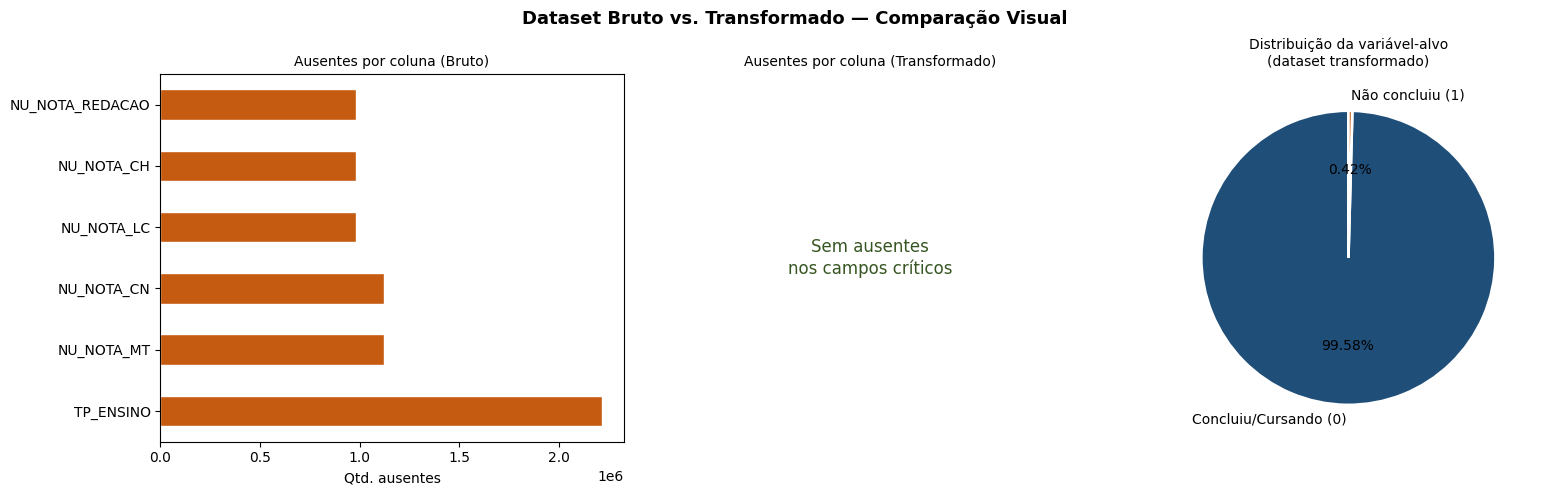


  📋 Amostra do dataset BRUTO COMPLETO (Todas as colunas analíticas):


,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q024,Q025
0,210057943671,14,M,2,2,1,1,NaN,0,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,A,A,A,B,3,B,B,B,B,A,A
1,210057516120,14,M,2,1,1,1,NaN,0,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,D,D,E,E,3,Q,D,E,E,E,B
2,210057280536,5,F,1,2,1,1,NaN,0,BA,1,1,1,1,421.1,546.0,498.8,565.3,760.0,E,F,A,D,2,B,A,B,C,A,B
3,210055724397,6,M,1,3,1,1,NaN,0,ES,1,1,1,1,490.7,388.6,357.8,416.0,320.0,C,A,A,B,3,A,A,C,D,B,B
4,210055097896,4,M,0,3,1,1,NaN,0,PA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,D,B,A,B,2,B,A,B,B,A,A



  📋 Amostra do dataset TRANSFORMADO COMPLETO (Todas as colunas + Variável-Alvo):


,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q024,Q025,NAO_CONCLUIU_EM,MEDIA_OBJETIVAS
0,210057943671,14,M,2,2,1,1,9,DF,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0,A,A,A,B,3,B,B,B,B,A,A,0,0.000000
1,210057516120,14,M,2,1,1,1,9,DF,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0,D,D,E,E,3,Q,D,E,E,E,B,0,0.000000
2,210057280536,5,F,1,2,1,1,9,BA,1,1,1,1,421.100006,546.000000,498.799988,565.299988,760.0,E,F,A,D,2,B,A,B,C,A,B,0,507.799988
3,210055724397,6,M,1,3,1,1,9,ES,1,1,1,1,490.700012,388.600006,357.799988,416.000000,320.0,C,A,A,B,3,A,A,C,D,B,B,0,413.279999
4,210055097896,4,M,0,3,1,1,9,PA,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0,D,B,A,B,2,B,A,B,B,A,A,0,0.000000



✅ Visualização comparativa completa e expandida concluída.


In [ ]:
# ============================================================
# Visualização comparativa: dataset bruto vs. transformado
#
# O professor solicitou uma visualização lado a lado para
# evidenciar o que o Transform modificou nos dados.
#
# Comparamos:
#   1. Shape (linhas e colunas) antes e depois
#   2. Tipos de dados antes e depois (Todas as colunas exibidas)
#   3. Valores ausentes antes e depois
#   4. Distribuição da variável-alvo (apenas no transformado)
#   5. Amostra visual completa de ambos os datasets
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

# ── Carregar dataset bruto (só as colunas analíticas, para comparação justa) ──
print('📂 Carregando dataset bruto para comparação...')
caminho_bruto = os.path.join(pasta_extracao, 'DADOS', 'MICRODADOS_ENEM_2022.csv')
colunas_para_comparar = colunas_analiticas + ['IN_TREINEIRO']
df_bruto = pd.read_csv(
    caminho_bruto, sep=';', encoding='latin-1',
    usecols=colunas_para_comparar, low_memory=False
)

# ── Carregar dataset transformado ──
df_transf = pd.read_parquet(CAMINHO_PARQUET)

print('\n' + '='*65)
print('   COMPARAÇÃO: DATASET BRUTO vs. TRANSFORMADO')
print('='*65)

# ── 1. Shape ──
print(f'\n  📐 Dimensões:')
print(f'  {"":30} {"BRUTO":>15} {"TRANSFORMADO":>15}')
print(f'  {"-"*62}')
print(f'  {"Linhas":<30} {len(df_bruto):>15,} {len(df_transf):>15,}')
print(f'  {"Colunas":<30} {df_bruto.shape[1]:>15} {df_transf.shape[1]:>15}')
print(f'  {"Memória (MB)":<30} {df_bruto.memory_usage(deep=True).sum()/(1024**2):>14.1f} {df_transf.memory_usage(deep=True).sum()/(1024**2):>14.1f}')

# ── 2. Valores ausentes ──
nulos_bruto  = df_bruto.isnull().sum().sum()
nulos_transf = df_transf.isnull().sum().sum()
print(f'\n  🔍 Valores ausentes totais:')
print(f'  {"Bruto":<30} {nulos_bruto:>15,}')
print(f'  {"Transformado":<30} {nulos_transf:>15,}')
print(f'  {"Redução":<30} {(1 - nulos_transf/nulos_bruto)*100 if nulos_bruto > 0 else 0:>14.1f}%')

# ── 3. Comparação de tipos por coluna (Expandido para todas as colunas) ──
print(f'\n  🔢 Comparação de tipos de dados (Todas as colunas em comum):')
print(f'  {"Coluna":<25} {"Tipo Bruto":>15} {"Tipo Transformado":>18}')
print(f'  {"-"*60}')
cols_comuns = [c for c in df_transf.columns if c in df_bruto.columns and c != 'NAO_CONCLUIU_EM']

# Removido o limite [:15] para printar a tabela completa de mapeamento de tipos
for col in sorted(cols_comuns):
    t_bruto  = str(df_bruto[col].dtype)
    t_transf = str(df_transf[col].dtype)
    flag = ' ← 🔄 Mudou!' if t_bruto != t_transf else ''
    print(f'  {col:<25} {t_bruto:>15} {t_transf:>18}{flag}')

# ── 4. Gráfico comparativo ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Bruto vs. Transformado — Comparação Visual', fontsize=13, fontweight='bold')

# Ausentes por coluna: bruto
nulos_col_bruto = df_bruto[cols_comuns].isnull().sum().sort_values(ascending=False)
nulos_col_bruto = nulos_col_bruto[nulos_col_bruto > 0].head(10)
if len(nulos_col_bruto) > 0:
    nulos_col_bruto.plot(kind='barh', ax=axes[0], color='#C55A11', edgecolor='white')
    axes[0].set_title('Ausentes por coluna (Bruto)', fontsize=10)
    axes[0].set_xlabel('Qtd. ausentes')
else:
    axes[0].text(0.5, 0.5, 'Sem ausentes', ha='center', va='center', fontsize=12)
    axes[0].set_title('Ausentes por coluna (Bruto)', fontsize=10)
    axes[0].axis('off')

# Ausentes por coluna: transformado
nulos_col_transf = df_transf.isnull().sum().sort_values(ascending=False)
nulos_col_transf = nulos_col_transf[nulos_col_transf > 0].head(10)
if len(nulos_col_transf) > 0:
    nulos_col_transf.plot(kind='barh', ax=axes[1], color='#375623', edgecolor='white')
    axes[1].set_title('Ausentes por coluna (Transformado)', fontsize=10)
    axes[1].set_xlabel('Qtd. ausentes')
else:
    axes[1].text(0.5, 0.5, 'Sem ausentes\nnos campos críticos', ha='center', va='center', fontsize=12, color='#375623')
    axes[1].set_title('Ausentes por coluna (Transformado)', fontsize=10)
    axes[1].axis('off')

# Distribuição da variável-alvo (só no transformado)
contagem = df_transf['NAO_CONCLUIU_EM'].value_counts().sort_index()
labels = ['Concluiu/Cursando (0)', 'Não concluiu (1)']
colors = ['#1F4E79', '#C55A11']
axes[2].pie(contagem.values, labels=labels, colors=colors,
            autopct='%1.2f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Distribuição da variável-alvo\n(dataset transformado)', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PASTA_PROCESSED, 'comparacao_bruto_transformado.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Amostras Completas (Sem cortes de colunas ou linhas) ──
# pd.option_context garante que a exibição expandida aconteça apenas aqui dentro, sem estragar o resto do notebook
with pd.option_context('display.max_columns', None, 'display.max_rows', 10, 'display.width', 1000):
    print('\n  📋 Amostra do dataset BRUTO COMPLETO (Todas as colunas analíticas):')
    # Removeu a seleção manual, puxando todas as colunas processadas na camada
    display(df_bruto.head(5))

    print('\n  📋 Amostra do dataset TRANSFORMADO COMPLETO (Todas as colunas + Variável-Alvo):')
    # Mostra o dataset transformado com a coluna de Target mapeada no final
    display(df_transf.head(5))

print('\n✅ Visualização comparativa completa e expandida concluída.')

  ESTATÍSTICA DESCRITIVA — DATASET TRANSFORMADO
  Shape: 2,963,373 linhas × 31 colunas
  Memória: 1842.6 MB

  📊 VARIÁVEIS NUMÉRICAS (notas e média):
----------------------------------------------------------------------


,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,MEDIA_OBJETIVAS
count,2963373.00,2963373.00,2963373.00,2963373.00,2963373.00,2963373.00
mean,324.49,363.12,356.15,353.60,424.34,349.34
std,243.27,253.22,247.94,276.14,333.61,246.87
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,437.70,482.10,474.20,442.30,540.00,463.80
75%,511.40,557.80,551.20,571.40,680.00,538.25
max,875.30,839.20,801.00,985.70,1000.00,839.80



  📊 VARIÁVEIS CATEGÓRICAS — distribuição de frequências:
----------------------------------------------------------------------

  TP_SEXO:
       F  Feminino                       1,786,341  ( 60.3%)  ██████████████████████████████
       M  Masculino                      1,177,032  ( 39.7%)  ███████████████████

  TP_COR_RACA:
       0  Não declarado                     56,084  (  1.9%)  
       1  Branca                         1,158,773  ( 39.1%)  ███████████████████
       2  Preta                            372,491  ( 12.6%)  ██████
       3  Parda                          1,301,016  ( 43.9%)  █████████████████████
       4  Amarela                           56,885  (  1.9%)  
       5  Indígena                          18,124  (  0.6%)  

  TP_ESCOLA:
       1  Não respondeu                  1,645,813  ( 55.5%)  ███████████████████████████
       2  Pública                        1,105,355  ( 37.3%)  ██████████████████
       3  Privada                          212,205  (  7.2%

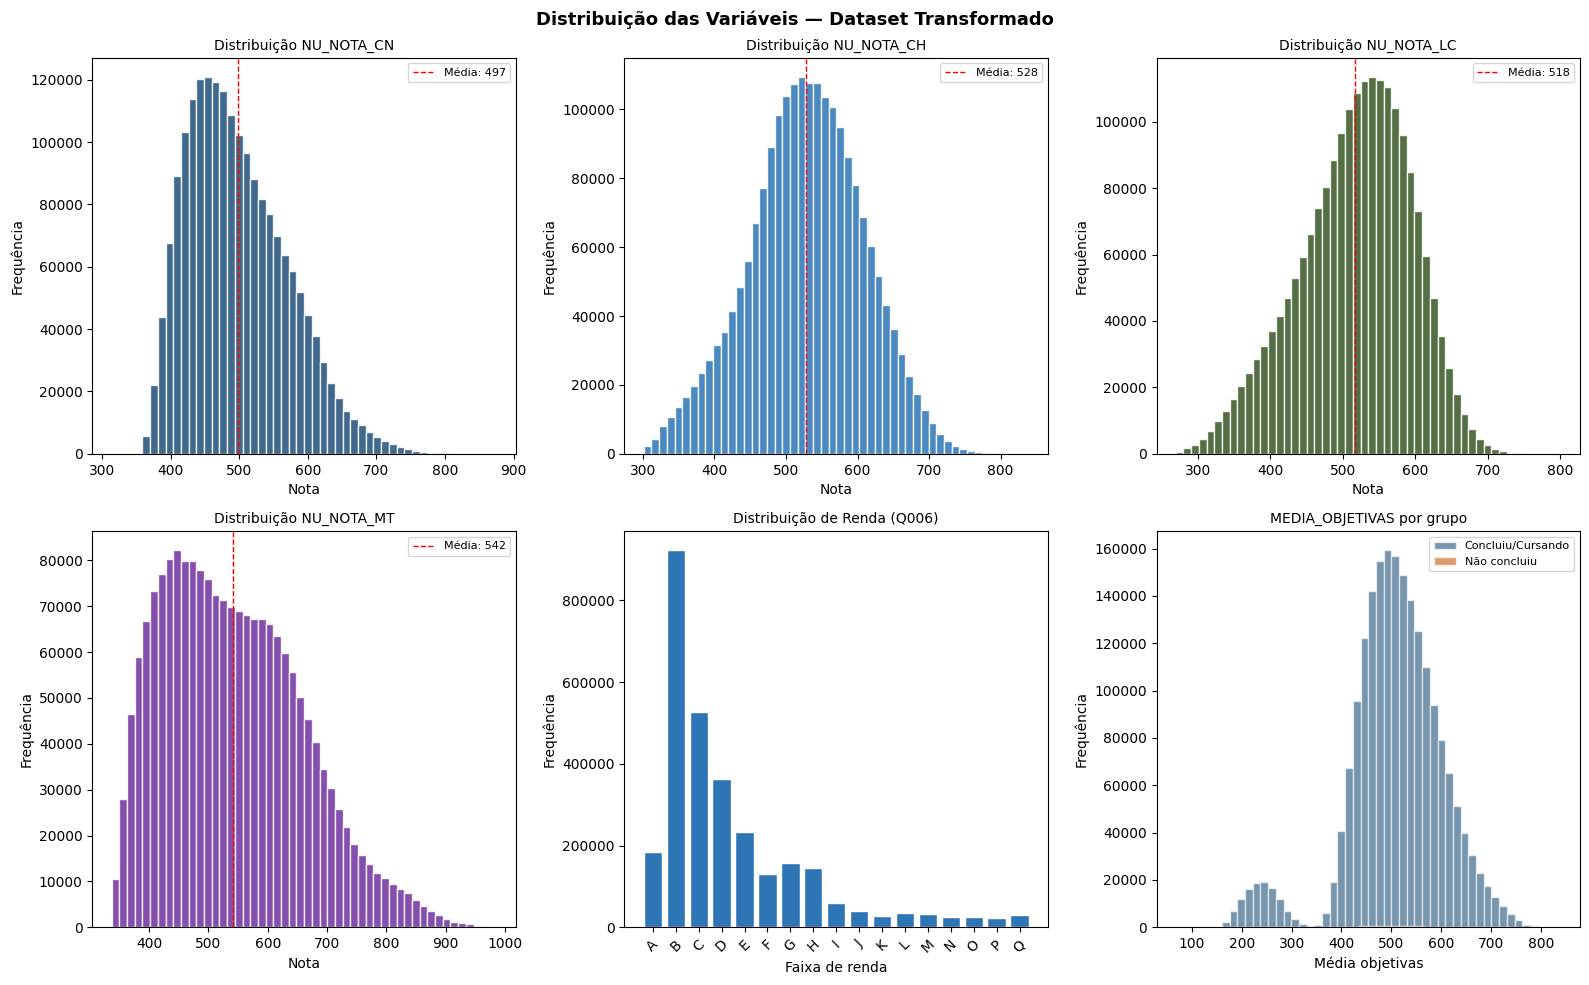


✅ Estatística descritiva concluída. Gráfico salvo em processed/


In [ ]:
# ============================================================
# Estatística descritiva de todas as variáveis do dataset
# transformado
#
# O professor solicitou uma análise estatística completa
# para entender a distribuição de cada variável antes
# de aplicar o modelo de Mineração.
#
# Cobrimos:
#   1. Estatísticas numéricas (média, desvio, min, max, quartis)
#   2. Frequências das variáveis categóricas
#   3. Correlação das variáveis numéricas com a variável-alvo
#   4. Gráficos de distribuição das notas e da renda
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_desc = pd.read_parquet(CAMINHO_PARQUET)

print('='*70)
print('  ESTATÍSTICA DESCRITIVA — DATASET TRANSFORMADO')
print('='*70)
print(f'  Shape: {df_desc.shape[0]:,} linhas × {df_desc.shape[1]} colunas')
print(f'  Memória: {df_desc.memory_usage(deep=True).sum()/(1024**2):.1f} MB')

# ── 1. Variáveis numéricas ──
print('\n  📊 VARIÁVEIS NUMÉRICAS (notas e média):')
print('-'*70)
cols_num = ['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO','MEDIA_OBJETIVAS']
desc_num = df_desc[cols_num].describe().round(2)
display(desc_num)

# ── 2. Variáveis categóricas — frequências ──
print('\n  📊 VARIÁVEIS CATEGÓRICAS — distribuição de frequências:')
print('-'*70)

mapeamentos = {
    'TP_SEXO':        {"M": "Masculino", "F": "Feminino"},
    'TP_COR_RACA':    {0:"Não declarado",1:"Branca",2:"Preta",3:"Parda",4:"Amarela",5:"Indígena",9:"Não informado"},
    'TP_ESCOLA':      {1:"Não respondeu",2:"Pública",3:"Privada",4:"Exterior"},
    'TP_ENSINO':      {1:"Regular",2:"EJA"},
    'TP_ST_CONCLUSAO':{1:"Já concluiu",2:"Concluirá em 2022",3:"Concluirá após 2022",4:"Não concluiu"},
    'NAO_CONCLUIU_EM':{0:"Não (concluiu/cursando)",1:"Sim (não concluiu)"},
    'Q006':           {"A":"Sem renda","B":"Até R$1.320","C":"R$1.320–R$1.980","D":"R$1.980–R$2.640",
                       "E":"R$2.640–R$3.300","F":"R$3.300–R$3.960","G":"R$3.960–R$5.280",
                       "H":"R$5.280–R$6.600","I":"R$6.600–R$7.920","J":"R$7.920–R$9.240",
                       "K":"R$9.240–R$10.560","L":"R$10.560–R$13.200","M":"R$13.200–R$15.840",
                       "N":"R$15.840–R$19.800","O":"R$19.800–R$26.400","P":"Acima de R$26.400"},
}

for col in ['TP_SEXO','TP_COR_RACA','TP_ESCOLA','TP_ENSINO','TP_ST_CONCLUSAO','NAO_CONCLUIU_EM','Q006']:
    if col not in df_desc.columns:
        continue
    freq = df_desc[col].value_counts(dropna=False).sort_index()
    mapa = mapeamentos.get(col, {})
    print(f'\n  {col}:')
    for val, qtd in freq.items():
        label = mapa.get(val, str(val))
        pct = qtd / len(df_desc) * 100
        barra = '█' * int(pct / 2)
        print(f'    {str(val):>4}  {label:<30} {qtd:>9,}  ({pct:>5.1f}%)  {barra}')

# ── 3. Correlação com a variável-alvo ──
print('\n  📊 CORRELAÇÃO COM NAO_CONCLUIU_EM (Pearson):')
print('-'*70)
cols_corr = cols_num + ['TP_COR_RACA','TP_ESCOLA','TP_FAIXA_ETARIA']
correlacoes = df_desc[cols_corr + ['NAO_CONCLUIU_EM']].corr()['NAO_CONCLUIU_EM'].drop('NAO_CONCLUIU_EM').sort_values()
for col, corr in correlacoes.items():
    barra = '█' * int(abs(corr) * 30)
    sinal = '+' if corr >= 0 else '-'
    print(f'  {col:<25} {sinal}{abs(corr):.4f}  {barra}')

# ── 4. Gráficos de distribuição ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuição das Variáveis — Dataset Transformado', fontsize=13, fontweight='bold')

cores = ['#1F4E79','#2E75B6','#375623','#7030A0','#C55A11']

# Distribuição das notas objetivas
for i, (col, cor) in enumerate(zip(['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT'], cores)):
    ax = axes[0, i] if i < 3 else axes[1, i-3]
    dados = df_desc[df_desc[col] > 0][col]
    ax.hist(dados, bins=50, color=cor, edgecolor='white', alpha=0.85)
    ax.axvline(dados.mean(), color='red', linestyle='--', linewidth=1, label=f'Média: {dados.mean():.0f}')
    ax.set_title(f'Distribuição {col}', fontsize=10)
    ax.set_xlabel('Nota'); ax.set_ylabel('Frequência')
    ax.legend(fontsize=8)

# Distribuição da renda (Q006)
if 'Q006' in df_desc.columns:
    freq_renda = df_desc['Q006'].value_counts().sort_index()
    axes[1, 1].bar(freq_renda.index.astype(str), freq_renda.values, color='#2E75B6', edgecolor='white')
    axes[1, 1].set_title('Distribuição de Renda (Q006)', fontsize=10)
    axes[1, 1].set_xlabel('Faixa de renda'); axes[1, 1].set_ylabel('Frequência')
    axes[1, 1].tick_params(axis='x', rotation=45)

# Distribuição da MEDIA_OBJETIVAS por grupo
for val, cor, label in [(0,'#1F4E79','Concluiu/Cursando'),(1,'#C55A11','Não concluiu')]:
    dados = df_desc[df_desc['NAO_CONCLUIU_EM']==val]['MEDIA_OBJETIVAS']
    dados = dados[dados > 0]
    axes[1, 2].hist(dados, bins=50, color=cor, alpha=0.6, label=label, edgecolor='white')
axes[1, 2].set_title('MEDIA_OBJETIVAS por grupo', fontsize=10)
axes[1, 2].set_xlabel('Média objetivas'); axes[1, 2].set_ylabel('Frequência')
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PASTA_PROCESSED, 'estatistica_descritiva.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Estatística descritiva concluída. Gráfico salvo em processed/')


In [ ]:
# ============================================================
# Criação de variáveis dummy para variáveis categóricas
#
# O professor solicitou a criação de dummies antes do modelo,
# especialmente para variáveis como cor/raça (TP_COR_RACA),
# que têm categorias sem ordem natural.
#
# Por que dummies são necessárias?
#   - Modelos como regressão logística assumem que as variáveis
#     numéricas têm relação linear com o alvo.
#   - Uma variável como TP_COR_RACA codificada como 1,2,3,4,5
#     implica uma ordem que não existe (Branca=1 < Preta=2?).
#   - Dummies criam uma coluna binária por categoria, eliminando
#     esse problema.
#
# Estratégia adotada (drop_first=True):
#   - Remove a primeira categoria de cada variável para evitar
#     multicolinearidade perfeita (dummy trap).
#   - A categoria removida torna-se a referência de comparação.
# ============================================================

import pandas as pd

df_modelo = pd.read_parquet(CAMINHO_PARQUET)

print('='*70)
print('  CRIAÇÃO DE VARIÁVEIS DUMMY')
print('='*70)
print(f'  Shape antes: {df_modelo.shape}')

# ── Variáveis que receberão dummies ──
# Critério: categóricas nominais sem ordem natural
# Excluímos ordinais (Q006 tem ordem de renda) e binárias (NAO_CONCLUIU_EM)
colunas_dummy = [
    'TP_COR_RACA',     # Raça: sem ordem natural entre categorias
    'TP_SEXO',         # Sexo: M/F sem ordem
    'TP_ESCOLA',       # Tipo de escola: pública/privada sem hierarquia
    'TP_ESTADO_CIVIL', # Estado civil: categorias nominais
    'TP_ENSINO',       # Tipo de ensino: regular/EJA
]

# Mapeamento de labels para os prefixos das dummies
prefixos = {
    'TP_COR_RACA':     'raca',
    'TP_SEXO':         'sexo',
    'TP_ESCOLA':       'escola',
    'TP_ESTADO_CIVIL': 'civil',
    'TP_ENSINO':       'ensino',
}

# Guardar colunas originais antes de expandir
colunas_antes = set(df_modelo.columns)

# Converter para string antes do get_dummies (garante prefixos legíveis)
for col in colunas_dummy:
    if col in df_modelo.columns:
        df_modelo[col] = df_modelo[col].astype(str)

# Criar dummies com drop_first=True (evita dummy trap)
df_modelo = pd.get_dummies(
    df_modelo,
    columns=[c for c in colunas_dummy if c in df_modelo.columns],
    prefix={c: prefixos[c] for c in colunas_dummy if c in df_modelo.columns},
    drop_first=True,
    dtype=int
)

colunas_depois = set(df_modelo.columns)
novas_colunas  = sorted(colunas_depois - colunas_antes)

print(f'  Shape depois: {df_modelo.shape}')
print(f'  Novas colunas criadas: {len(novas_colunas)}')

print(f'\n  Dummies geradas por variável:')
print('-'*70)
for col_orig, prefixo in prefixos.items():
    dummies_col = [c for c in novas_colunas if c.startswith(prefixo + '_')]
    if dummies_col:
        print(f'  {col_orig} → {len(dummies_col)+1} categorias → {len(dummies_col)} dummies (1 descartada como referência):')
        for d in dummies_col:
            soma = df_modelo[d].sum()
            pct  = soma / len(df_modelo) * 100
            print(f'     {d:<35} {soma:>9,}  ({pct:.1f}%)')

# ── Verificação: sem valores ausentes nas novas colunas ──
nulos_dummies = df_modelo[novas_colunas].isnull().sum().sum()
print(f'\n  Ausentes nas novas colunas dummy: {nulos_dummies}')

# ── Salvar dataset com dummies ──
CAMINHO_PARQUET_MODELO = os.path.join(PASTA_PROCESSED, 'enem_2022_modelo.parquet')
df_modelo.to_parquet(CAMINHO_PARQUET_MODELO, index=False, compression='snappy')
tamanho_modelo_mb = os.path.getsize(CAMINHO_PARQUET_MODELO) / (1024**2)

print(f'\n  Dataset com dummies salvo em:')
print(f'  {CAMINHO_PARQUET_MODELO}')
print(f'  Tamanho: {tamanho_modelo_mb:.2f} MB')
print(f'  Shape final: {df_modelo.shape}')
print(f'\n  ℹ️  Este arquivo será usado pela etapa de Mineração.')
print(f'  ℹ️  Variáveis ordinais (Q001–Q009, Q024, Q025, Q006) mantidas como inteiros')
print(f'      pois têm ordem natural e podem ser tratadas como numéricas no modelo.')
print('\n✅ Variáveis dummy criadas com sucesso.')


  CRIAÇÃO DE VARIÁVEIS DUMMY
  Shape antes: (2963373, 31)
  Shape depois: (2963373, 40)
  Novas colunas criadas: 14

  Dummies geradas por variável:
----------------------------------------------------------------------
  TP_COR_RACA → 6 categorias → 5 dummies (1 descartada como referência):
     raca_1                              1,158,773  (39.1%)
     raca_2                                372,491  (12.6%)
     raca_3                              1,301,016  (43.9%)
     raca_4                                 56,885  (1.9%)
     raca_5                                 18,124  (0.6%)
  TP_SEXO → 2 categorias → 1 dummies (1 descartada como referência):
     sexo_M                              1,177,032  (39.7%)
  TP_ESCOLA → 3 categorias → 2 dummies (1 descartada como referência):
     escola_2                            1,105,355  (37.3%)
     escola_3                              212,205  (7.2%)
  TP_ESTADO_CIVIL → 5 categorias → 4 dummies (1 descartada como referência):
     civil_1 

In [ ]:
# ============================================================
# Tradução do dataset: labels em português
#
# O professor solicitou a tradução do dataset antes de aplicar
# o modelo — ou seja, substituir os códigos numéricos/letras
# por labels legíveis em português.
#
# Objetivo:
#   - Facilitar a interpretação dos resultados do modelo
#   - Tornar as saídas (importância de features, matriz de
#     confusão, relatório de classificação) mais legíveis
#   - Documentar o significado real de cada código do INEP
#
# Atenção: a tradução é gerada como um dicionário de referência
# e como um DataFrame separado com labels — o dataset numérico
# original (enem_2022_modelo.parquet) é mantido para o modelo,
# pois algoritmos de ML precisam de valores numéricos.
# ============================================================

import pandas as pd
import json

# ── Dicionário de tradução completo ──
TRADUCAO = {
    'TP_SEXO': {
        'M': 'Masculino',
        'F': 'Feminino',
    },
    'TP_COR_RACA': {
        0: 'Não declarado',
        1: 'Branca',
        2: 'Preta',
        3: 'Parda',
        4: 'Amarela',
        5: 'Indígena',
        9: 'Não informado',
    },
    'TP_ESCOLA': {
        1: 'Não respondeu',
        2: 'Pública',
        3: 'Privada',
        4: 'Exterior',
    },
    'TP_ESTADO_CIVIL': {
        0: 'Não informado',
        1: 'Solteiro(a)',
        2: 'Casado(a)/Uniao estavel',
        3: 'Divorciado(a)/Separado(a)',
        4: 'Viuvo(a)',
        9: 'Nao informado',
    },
    'TP_ENSINO': {
        1: 'Regular',
        2: 'EJA (Educacao de Jovens e Adultos)',
    },
    'TP_ST_CONCLUSAO': {
        1: 'Ja concluiu o Ensino Medio',
        2: 'Concluira em 2022',
        3: 'Concluira apos 2022',
        4: 'Nao concluiu e nao esta cursando',
    },
    'NAO_CONCLUIU_EM': {
        0: 'Nao (concluiu ou esta cursando)',
        1: 'Sim (nao concluiu o Ensino Medio)',
    },
    'TP_FAIXA_ETARIA': {
        1:'Menor de 17 anos', 2:'17 anos', 3:'18 anos', 4:'19 anos',
        5:'20 anos', 6:'21 anos', 7:'22 anos', 8:'23 anos', 9:'24 anos',
        10:'25 anos', 11:'Entre 26 e 30 anos', 12:'Entre 31 e 35 anos',
        13:'Entre 36 e 40 anos', 14:'Entre 41 e 45 anos',
        15:'Entre 46 e 50 anos', 16:'Entre 51 e 55 anos',
        17:'Entre 56 e 60 anos', 18:'Entre 61 e 65 anos',
        19:'Entre 66 e 70 anos', 20:'Maior de 70 anos',
    },
    'TP_PRESENCA_CN': {0:'Faltou',1:'Presente',2:'Eliminado'},
    'TP_PRESENCA_CH': {0:'Faltou',1:'Presente',2:'Eliminado'},
    'TP_PRESENCA_LC': {0:'Faltou',1:'Presente',2:'Eliminado'},
    'TP_PRESENCA_MT': {0:'Faltou',1:'Presente',2:'Eliminado'},
    'Q001': {
        'A':'Nunca estudou','B':'Ate 5o ano incompleto','C':'5o ano completo',
        'D':'6o ao 9o ano','E':'Ensino Fundamental completo',
        'F':'Ensino Medio incompleto','G':'Ensino Medio completo',
        'H':'Educacao Superior incompleta','I':'Educacao Superior completa',
        'J':'Pos-graduacao','K':'Nao sei',
    },
    'Q002': {
        'A':'Nunca estudou','B':'Ate 5o ano incompleto','C':'5o ano completo',
        'D':'6o ao 9o ano','E':'Ensino Fundamental completo',
        'F':'Ensino Medio incompleto','G':'Ensino Medio completo',
        'H':'Educacao Superior incompleta','I':'Educacao Superior completa',
        'J':'Pos-graduacao','K':'Nao sei',
    },
    'Q006': {
        'A':'Sem renda','B':'Ate R$1.320','C':'R$1.320 a R$1.980',
        'D':'R$1.980 a R$2.640','E':'R$2.640 a R$3.300','F':'R$3.300 a R$3.960',
        'G':'R$3.960 a R$5.280','H':'R$5.280 a R$6.600','I':'R$6.600 a R$7.920',
        'J':'R$7.920 a R$9.240','K':'R$9.240 a R$10.560','L':'R$10.560 a R$13.200',
        'M':'R$13.200 a R$15.840','N':'R$15.840 a R$19.800',
        'O':'R$19.800 a R$26.400','P':'Acima de R$26.400',
    },
    'Q024': {'A':'Nao','B':'Sim, um','C':'Sim, dois ou mais'},
    'Q025': {'A':'Nao','B':'Sim'},
}

# ── Nomes das colunas em português ──
NOMES_COLUNAS_PT = {
    'NU_INSCRICAO':    'Numero de Inscricao',
    'TP_FAIXA_ETARIA': 'Faixa Etaria',
    'TP_SEXO':         'Sexo',
    'TP_COR_RACA':     'Cor ou Raca',
    'TP_ESCOLA':       'Tipo de Escola',
    'TP_ST_CONCLUSAO': 'Situacao de Conclusao do EM',
    'TP_ESTADO_CIVIL': 'Estado Civil',
    'TP_ENSINO':       'Tipo de Ensino',
    'SG_UF_PROVA':     'UF da Prova',
    'NU_NOTA_CN':      'Nota Ciencias da Natureza',
    'NU_NOTA_CH':      'Nota Ciencias Humanas',
    'NU_NOTA_LC':      'Nota Linguagens e Codigos',
    'NU_NOTA_MT':      'Nota Matematica',
    'NU_NOTA_REDACAO': 'Nota Redacao',
    'TP_PRESENCA_CN':  'Presenca CN',
    'TP_PRESENCA_CH':  'Presenca CH',
    'TP_PRESENCA_LC':  'Presenca LC',
    'TP_PRESENCA_MT':  'Presenca MT',
    'Q001':            'Escolaridade do Pai',
    'Q002':            'Escolaridade da Mae',
    'Q003':            'Ocupacao do Pai',
    'Q004':            'Ocupacao da Mae',
    'Q005':            'Pessoas no Domicilio',
    'Q006':            'Renda Familiar',
    'Q007':            'Possui Empregada Domestica',
    'Q008':            'Possui Banheiro',
    'Q009':            'Possui Carro',
    'Q024':            'Acesso a Internet em Casa',
    'Q025':            'Possui Computador',
    'NAO_CONCLUIU_EM': 'Nao Concluiu o Ensino Medio (alvo)',
    'MEDIA_OBJETIVAS': 'Media das Notas Objetivas',
}

# ── Aplicar tradução para um DataFrame de leitura humana ──
df_original = pd.read_parquet(CAMINHO_PARQUET)
df_traduzido = df_original.copy()

for col, mapa in TRADUCAO.items():
    if col in df_traduzido.columns:
        df_traduzido[col] = df_traduzido[col].map(mapa).fillna(df_traduzido[col])

# Renomear colunas
df_traduzido = df_traduzido.rename(columns=NOMES_COLUNAS_PT)

# Exibir amostra
print('='*70)
print('  DATASET TRADUZIDO — AMOSTRA (10 linhas)')
print('='*70)
cols_exibir = [
    'Faixa Etaria', 'Sexo', 'Cor ou Raca', 'Tipo de Escola',
    'Renda Familiar', 'Nota Matematica', 'Nao Concluiu o Ensino Medio (alvo)'
]
cols_exibir = [c for c in cols_exibir if c in df_traduzido.columns]
display(df_traduzido[cols_exibir].sample(10, random_state=42))

# ── Salvar dicionário de tradução como JSON ──
caminho_traducao = os.path.join(PASTA_PROCESSED, 'dicionario_traducao.json')
# Converter chaves inteiras para string (JSON não aceita int como chave)
traducao_serializada = {
    col: {str(k): v for k, v in mapa.items()}
    for col, mapa in TRADUCAO.items()
}
traducao_serializada['_nomes_colunas_pt'] = NOMES_COLUNAS_PT
with open(caminho_traducao, 'w', encoding='utf-8') as f:
    json.dump(traducao_serializada, f, ensure_ascii=False, indent=4)

print(f'\n  Dicionário de tradução salvo em:')
print(f'  {caminho_traducao}')
print(f'\n  ℹ️  O dataset NUMÉRICO (enem_2022_modelo.parquet) é usado no modelo ML.')
print(f'  ℹ️  O dicionario_traducao.json é usado para interpretar os resultados.')
print(f'  ℹ️  Ao exibir uma feature importance, use NOMES_COLUNAS_PT para traduzir.')
print('\n✅ Tradução concluída.')


  DATASET TRADUZIDO — AMOSTRA (10 linhas)


,Faixa Etaria,Sexo,Cor ou Raca,Tipo de Escola,Renda Familiar,Nota Matematica,Nao Concluiu o Ensino Medio (alvo)
278966,18 anos,Feminino,Preta,Não respondeu,Ate R$1.320,400.299988,Nao (concluiu ou esta cursando)
2677359,18 anos,Masculino,Branca,Não respondeu,Ate R$1.320,607.400024,Nao (concluiu ou esta cursando)
1755086,18 anos,Feminino,Parda,Pública,Ate R$1.320,0.000000,Nao (concluiu ou esta cursando)
1986650,17 anos,Masculino,Branca,Privada,Q,666.000000,Nao (concluiu ou esta cursando)
459823,20 anos,Feminino,Parda,Não respondeu,R$5.280 a R$6.600,849.000000,Nao (concluiu ou esta cursando)
1841533,22 anos,Masculino,Parda,Pública,Sem renda,0.000000,Nao (concluiu ou esta cursando)
2734848,Entre 26 e 30 anos,Feminino,Parda,Não respondeu,R$5.280 a R$6.600,0.000000,Nao (concluiu ou esta cursando)
1036309,19 anos,Feminino,Parda,Não respondeu,Ate R$1.320,0.000000,Nao (concluiu ou esta cursando)
2328743,17 anos,Feminino,Amarela,Pública,R$1.980 a R$2.640,635.599976,Nao (concluiu ou esta cursando)
2676204,21 anos,Masculino,Parda,Não respondeu,Ate R$1.320,0.000000,Nao (concluiu ou esta cursando)



  Dicionário de tradução salvo em:
  /content/drive/MyDrive/data_major/processed/dicionario_traducao.json

  ℹ️  O dataset NUMÉRICO (enem_2022_modelo.parquet) é usado no modelo ML.
  ℹ️  O dicionario_traducao.json é usado para interpretar os resultados.
  ℹ️  Ao exibir uma feature importance, use NOMES_COLUNAS_PT para traduzir.

✅ Tradução concluída.


In [ ]:
import pandas as pd

# Caminho que você definiu no seu notebook para o arquivo final
caminho_final = "/content/drive/MyDrive/data_major/processed/enem_2022_tratado.parquet" # Verifique se o nome é esse mesmo

# Lendo o arquivo que acabou de ser gerado
df_verificacao = pd.read_parquet(caminho_final)

# Visualizando uma amostra aleatória de 10 linhas
display(df_verificacao.sample(20))

,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,SG_UF_PROVA,TP_PRESENCA_CN,...,Q004,Q005,Q006,Q007,Q008,Q009,Q024,Q025,NAO_CONCLUIU_EM,MEDIA_OBJETIVAS
1982683,210055131988,2,F,1,1,2,2,1,MS,1,...,B,3,G,A,C,E,B,B,0,452.750000
450226,210056514060,3,M,1,3,2,2,1,SP,0,...,D,4,M,A,B,C,B,B,0,0.000000
1534588,210055943177,3,F,1,1,1,1,9,SP,0,...,B,4,G,A,C,D,B,B,0,0.000000
1166448,210057755413,3,M,1,1,2,2,1,PB,1,...,B,5,B,A,B,D,C,B,0,494.029999
698111,210057399158,11,F,1,1,1,1,9,RJ,0,...,B,4,C,A,B,C,A,B,0,0.000000
1905701,210057802244,4,F,1,3,1,1,9,MG,0,...,A,1,C,A,B,C,A,B,0,0.000000
441951,210057394785,4,F,1,2,1,1,9,RJ,0,...,B,4,C,A,B,D,A,B,0,0.000000
1042950,210056128119,5,F,1,3,1,1,9,MA,1,...,B,5,A,A,B,D,A,B,0,450.950012
2658575,210056397548,4,M,1,1,2,2,1,ES,1,...,B,4,D,A,C,C,B,B,0,420.529999
360847,210055534686,3,M,1,3,2,2,1,PB,1,...,B,5,B,A,B,C,A,B,0,461.320007


/tmp/ipykernel_3427/937803123.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status, y=etapas, palette=colors_status, ax=ax3, edgecolor='black')
/tmp/ipykernel_3427/937803123.py:83: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3427/937803123.py:83: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3427/937803123.py:83: UserWarning: Glyph 127959 (\N{BUILDING CONSTRUCTION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3427/937803123.py:83: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_3427/937803123.py:83: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing f

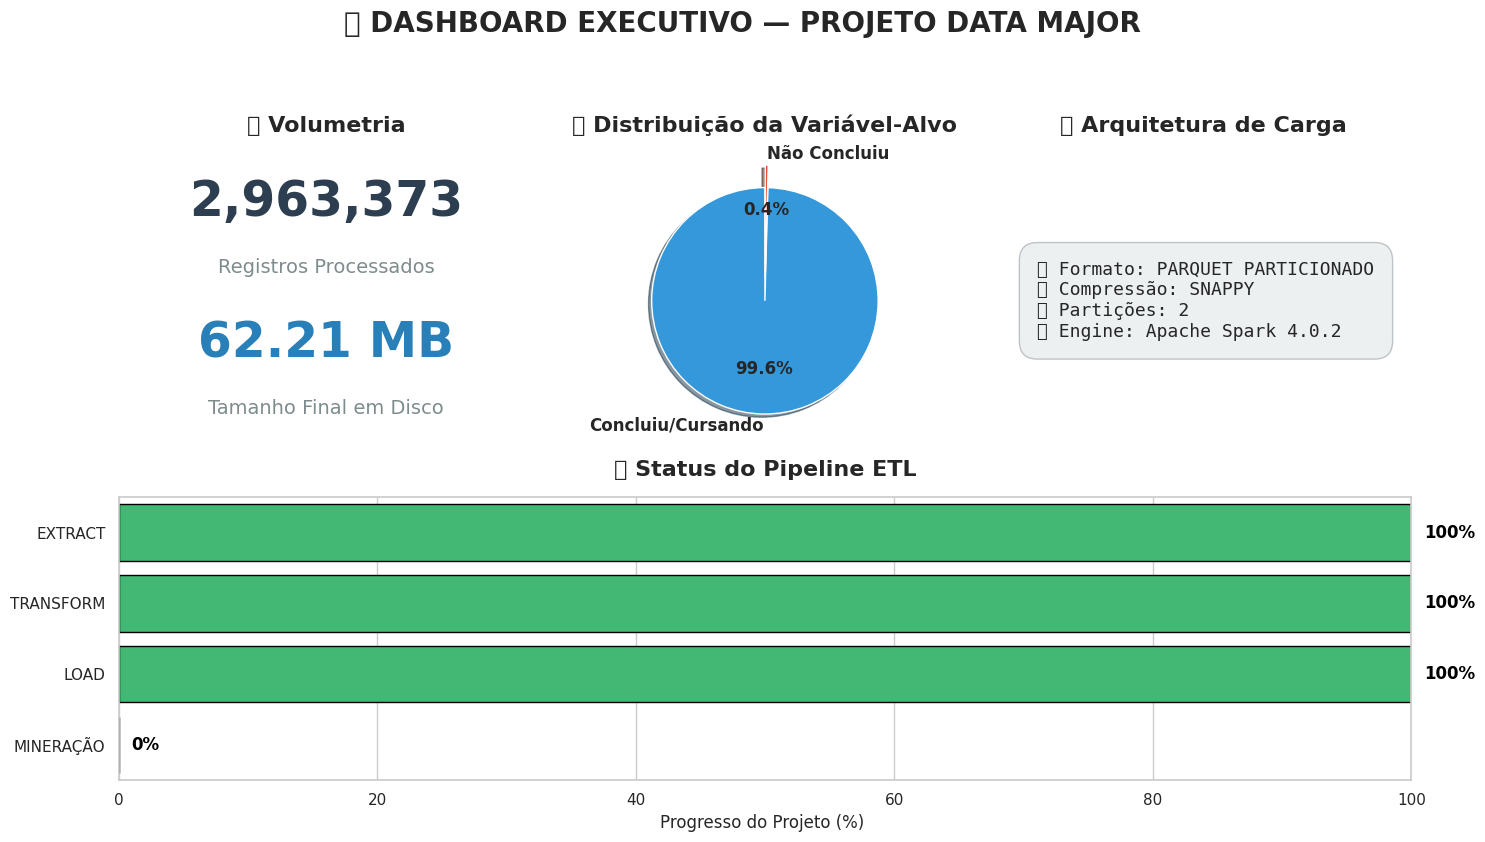


 ✅ PIPELINE FINALIZADO COM SUCESSO | DATASET PRONTO PARA MINERAÇÃO DE DADOS


In [ ]:
# ============================================================
# Dashboard Visual de Resultados Consolidados
# ============================================================

import json
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def find_metadata():
    patterns = [
        '/content/drive/MyDrive/data_major/load_metadata.json',
        '/content/drive/MyDrive/data_major*/load_metadata.json',
        '/content/data_major/load_metadata.json',
        './load_metadata.json'
    ]
    for p in patterns:
        matches = glob.glob(p)
        if matches: return os.path.dirname(matches[0])
    return None

project_path = find_metadata()

if project_path:
    try:
        with open(os.path.join(project_path, 'load_metadata.json'), 'r', encoding='utf-8') as f:
            meta = json.load(f)

        # Configuração de Estilo
        sns.set_theme(style="whitegrid")
        fig = plt.figure(figsize=(15, 8))
        gs = fig.add_gridspec(2, 3)
        fig.suptitle('🏆 DASHBOARD EXECUTIVO — PROJETO DATA MAJOR', fontsize=20, fontweight='bold', y=1.05)

        # 1. Card de Métricas Gerais (Texto estilizado)
        ax0 = fig.add_subplot(gs[0, 0])
        ax0.axis('off')
        ax0.text(0.5, 0.8, f"{meta['dados']['linhas_totais']:,}", fontsize=35, fontweight='bold', ha='center', color='#2c3e50')
        ax0.text(0.5, 0.6, "Registros Processados", fontsize=14, ha='center', color='#7f8c8d')
        ax0.text(0.5, 0.3, f"{meta['armazenamento']['tamanho_mb']:.2f} MB", fontsize=35, fontweight='bold', ha='center', color='#2980b9')
        ax0.text(0.5, 0.1, "Tamanho Final em Disco", fontsize=14, ha='center', color='#7f8c8d')
        ax0.set_title("📊 Volumetria", fontsize=16, fontweight='bold', pad=20)

        # 2. Gráfico de Pizza: Variável-Alvo
        ax1 = fig.add_subplot(gs[0, 1])
        labels = ['Concluiu/Cursando', 'Não Concluiu']
        sizes = [meta['dados']['concluiu_ou_cursando'], meta['dados']['nao_concluiu_em']]
        colors = ['#3498db', '#e74c3c']
        explode = (0, 0.2)
        ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors,
                textprops={'fontsize': 12, 'fontweight': 'bold'}, shadow=True)
        ax1.set_title("🎯 Distribuição da Variável-Alvo", fontsize=16, fontweight='bold', pad=20)

        # 3. Info de Arquitetura
        ax2 = fig.add_subplot(gs[0, 2])
        ax2.axis('off')
        info_text = (
            f"🔹 Formato: {meta['armazenamento']['tipo'].upper()}\n"
            f"🔹 Compressão: {meta['armazenamento']['compressao'].upper()}\n"
            f"🔹 Partições: {meta['armazenamento']['num_particoes']}\n"
            f"🔹 Engine: {meta['engine']['tipo']} {meta['engine']['versao']}"
        )
        ax2.text(0.1, 0.5, info_text, fontsize=13, va='center', family='monospace',
                 bbox=dict(boxstyle="round,pad=1", fc="#ecf0f1", ec="#bdc3c7"))
        ax2.set_title("🏗️ Arquitetura de Carga", fontsize=16, fontweight='bold', pad=20)

        # 4. Timeline do Pipeline (Barra Horizontal)
        ax3 = fig.add_subplot(gs[1, :])
        etapas = ['EXTRACT', 'TRANSFORM', 'LOAD', 'MINERAÇÃO']
        status = [100, 100, 100, 0]
        colors_status = ['#2ecc71', '#2ecc71', '#2ecc71', '#f1c40f']

        sns.barplot(x=status, y=etapas, palette=colors_status, ax=ax3, edgecolor='black')
        ax3.set_xlim(0, 100)
        ax3.set_xlabel("Progresso do Projeto (%) ", fontsize=12)
        ax3.set_title("🔄 Status do Pipeline ETL", fontsize=16, fontweight='bold', pad=15)

        for i, v in enumerate(status):
            ax3.text(v + 1, i, f"{v}%", color='black', va='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

        print("\n" + "="*90)
        print(" ✅ PIPELINE FINALIZADO COM SUCESSO | DATASET PRONTO PARA MINERAÇÃO DE DADOS")
        print("="*90)

    except Exception as e:
        print(f"\n ❌ Erro ao renderizar dashboard: {e}")
else:
    print("\n ⚠️  Aguardando execução do pipeline para gerar o dashboard visual.")
    print(" Certifique-se de que a pasta 'data_major' com os arquivos .json está acessível.")


# Etapa Mineração

### Regressão Linear Múltipla

Nesta etapa, a mineração será realizada com **Regressão Linear Múltipla** para explicar a `NOTA_FINAL` dos participantes do ENEM 2022.

A modelagem usará apenas as variáveis solicitadas:

- situação de presença agregada em formato binário: presente ou ausente;
- raça dummyzada;
- sexo dummyzado.

A variável de escola será removida da mineração e não entrará no modelo.


In [ ]:
import os
import json
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
sns.set(style="whitegrid")

print("Bibliotecas da etapa de Mineração importadas com sucesso.")

Bibliotecas da etapa de Mineração importadas com sucesso.


In [ ]:
# ============================================================
# Etapa Mineração - Carregamento do dataset preparado
# ============================================================

if "CAMINHO_PARQUET_MODELO" not in globals():
    CAMINHO_PARQUET_MODELO = os.path.join(
        "/content/drive/MyDrive/data_major",
        "processed",
        "enem_2022_modelo.parquet"
    )

print("Carregando dataset de modelagem:")
print(CAMINHO_PARQUET_MODELO)

df_mineracao = pd.read_parquet(CAMINHO_PARQUET_MODELO)

print("\nDataset carregado com sucesso.")
print(f"Linhas : {df_mineracao.shape[0]:,}")
print(f"Colunas: {df_mineracao.shape[1]:,}")

display(df_mineracao.head())

Carregando dataset de modelagem:
/content/drive/MyDrive/data_major/processed/enem_2022_modelo.parquet

Dataset carregado com sucesso.
Linhas : 2,963,373
Colunas: 40


,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_ST_CONCLUSAO,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,...,raca_5,sexo_M,escola_2,escola_3,civil_1,civil_2,civil_3,civil_4,ensino_2,ensino_9
0,210057943671,14,1,DF,0,0,0,0,0.000000,0.000000,...,0,1,0,0,0,1,0,0,0,1
1,210057516120,14,1,DF,0,0,0,0,0.000000,0.000000,...,0,1,0,0,0,1,0,0,0,1
2,210057280536,5,1,BA,1,1,1,1,421.100006,546.000000,...,0,0,0,0,1,0,0,0,0,1
3,210055724397,6,1,ES,1,1,1,1,490.700012,388.600006,...,0,1,0,0,1,0,0,0,0,1
4,210055097896,4,1,PA,0,0,0,0,0.000000,0.000000,...,0,1,0,0,0,0,0,0,0,1


In [ ]:
# ============================================================
# Etapa Mineração - Verificação inicial do dataset
# ============================================================

print("="*70)
print("VERIFICAÇÃO INICIAL DO DATASET DE MINERAÇÃO")
print("="*70)

print("\nDimensão do dataset:")
print(df_mineracao.shape)

print("\nTipos de dados:")
display(df_mineracao.dtypes.value_counts())

print("\nValores ausentes totais:")
print(df_mineracao.isnull().sum().sum())

colunas_escola_existentes = [
    col for col in df_mineracao.columns
    if col == "TP_ESCOLA" or col.startswith("escola_")
]

print("\nColunas de escola encontradas e excluídas da mineração:")
print(colunas_escola_existentes if colunas_escola_existentes else "Nenhuma")

VERIFICAÇÃO INICIAL DO DATASET DE MINERAÇÃO

Dimensão do dataset:
(2963373, 40)

Tipos de dados:


,count
int64,16
object,10
int8,7
float32,6
string[python],1



Valores ausentes totais:
0

Colunas de escola encontradas e excluídas da mineração:
['escola_2', 'escola_3']


In [ ]:
# ============================================================
# Etapa Mineração - Construção da nota final e presença binária
# ============================================================

colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO"
]
colunas_notas = [col for col in colunas_notas if col in df_mineracao.columns]

if not colunas_notas:
    raise ValueError("Nenhuma coluna de nota foi encontrada para calcular NOTA_FINAL.")

df_mineracao["NOTA_FINAL"] = (
    df_mineracao[colunas_notas]
    .apply(pd.to_numeric, errors="coerce")
    .mean(axis=1)
    .round(2)
)

colunas_presenca = [
    "TP_PRESENCA_CN",
    "TP_PRESENCA_CH",
    "TP_PRESENCA_LC",
    "TP_PRESENCA_MT"
]
colunas_presenca = [col for col in colunas_presenca if col in df_mineracao.columns]

if colunas_presenca:
    presencas = df_mineracao[colunas_presenca].apply(pd.to_numeric, errors="coerce")
    df_mineracao["PRESENTE"] = (presencas.eq(1).all(axis=1)).astype(int)
    criterio_presenca = "PRESENTE = 1 quando o participante esteve presente em todas as provas objetivas disponíveis; 0 caso contrário."
else:
    df_mineracao["PRESENTE"] = (df_mineracao["NOTA_FINAL"] > 0).astype(int)
    criterio_presenca = "PRESENTE = 1 inferido por NOTA_FINAL maior que zero, pois colunas de presença não estavam disponíveis."

print("="*70)
print("VARIÁVEIS CRIADAS PARA A MINERAÇÃO")
print("="*70)

print(f"\nColunas usadas em NOTA_FINAL: {colunas_notas}")
print(criterio_presenca)

print("\nResumo da NOTA_FINAL:")
display(df_mineracao["NOTA_FINAL"].describe().round(2))

print("\nDistribuição de presença:")
display(
    df_mineracao["PRESENTE"]
    .map({0: "Ausente", 1: "Presente"})
    .value_counts()
    .rename_axis("Situacao")
    .reset_index(name="Quantidade")
)


VARIÁVEIS CRIADAS PARA A MINERAÇÃO

Colunas usadas em NOTA_FINAL: ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
PRESENTE = 1 quando o participante esteve presente em todas as provas objetivas disponíveis; 0 caso contrário.

Resumo da NOTA_FINAL:


,NOTA_FINAL
count,2963373.00
mean,364.34
std,259.35
min,0.00
25%,0.00
50%,478.52
75%,566.06
max,855.98



Distribuição de presença:


,Situacao,Quantidade
0,Presente,1927753
1,Ausente,1035620


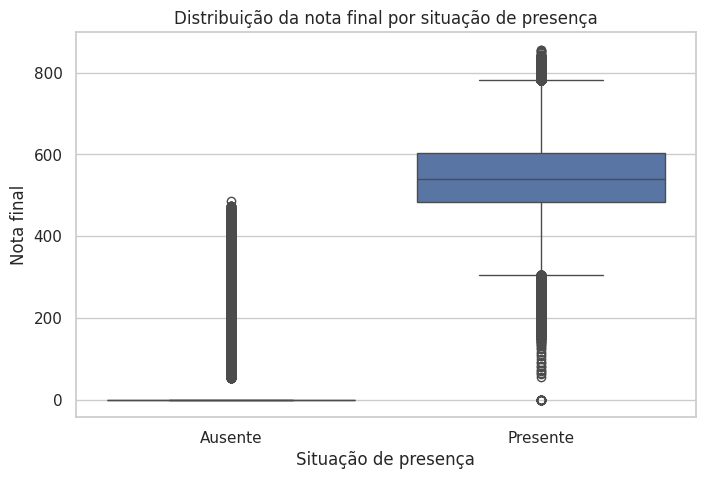

In [ ]:
# ============================================================
# Etapa Mineração - Visualização da nota final por presença
# ============================================================

df_plot_presenca = df_mineracao[["PRESENTE", "NOTA_FINAL"]].copy()
df_plot_presenca["Situacao"] = df_plot_presenca["PRESENTE"].map({0: "Ausente", 1: "Presente"})

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_plot_presenca,
    x="Situacao",
    y="NOTA_FINAL",
    order=["Ausente", "Presente"]
)

plt.title("Distribuição da nota final por situação de presença")
plt.xlabel("Situação de presença")
plt.ylabel("Nota final")
plt.show()

In [ ]:
# ============================================================
# Etapa Mineração - Seleção das variáveis explicativas
# ============================================================

# Raça e sexo já foram dummyzadas na etapa de Pré-Mineração.
# Caso o notebook seja executado sem aquela etapa, este bloco cria as dummies aqui.

df_regressao = df_mineracao.copy()

if "TP_COR_RACA" in df_regressao.columns and not any(col.startswith("raca_") for col in df_regressao.columns):
    df_regressao["TP_COR_RACA"] = df_regressao["TP_COR_RACA"].astype(str)
    dummies_raca = pd.get_dummies(df_regressao["TP_COR_RACA"], prefix="raca", drop_first=True, dtype=int)
    df_regressao = pd.concat([df_regressao, dummies_raca], axis=1)

if "TP_SEXO" in df_regressao.columns and not any(col.startswith("sexo_") for col in df_regressao.columns):
    df_regressao["TP_SEXO"] = df_regressao["TP_SEXO"].astype(str)
    dummies_sexo = pd.get_dummies(df_regressao["TP_SEXO"], prefix="sexo", drop_first=True, dtype=int)
    df_regressao = pd.concat([df_regressao, dummies_sexo], axis=1)

colunas_raca = sorted([col for col in df_regressao.columns if col.startswith("raca_")])
colunas_sexo = sorted([col for col in df_regressao.columns if col.startswith("sexo_")])
colunas_escola_removidas = sorted([
    col for col in df_regressao.columns
    if col == "TP_ESCOLA" or col.startswith("escola_")
])

colunas_modelo = ["PRESENTE"] + colunas_raca + colunas_sexo

if len(colunas_raca) == 0:
    raise ValueError("Nenhuma variável de raça dummyzada foi encontrada ou criada.")

if len(colunas_sexo) == 0:
    raise ValueError("Nenhuma variável de sexo dummyzada foi encontrada ou criada.")

X = df_regressao[colunas_modelo].copy()
y = df_regressao["NOTA_FINAL"].copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

y = pd.to_numeric(y, errors="coerce")

base_modelo = pd.concat([X, y.rename("NOTA_FINAL")], axis=1).dropna()
X = base_modelo[colunas_modelo]
y = base_modelo["NOTA_FINAL"]

print("="*70)
print("VARIÁVEIS DO MODELO")
print("="*70)

print(f"\nVariável-alvo: NOTA_FINAL")
print(f"Variáveis explicativas ({len(colunas_modelo)}): {colunas_modelo}")
print(f"Colunas de escola removidas: {colunas_escola_removidas if colunas_escola_removidas else 'Nenhuma'}")
print(f"Dimensão de X: {X.shape}")
print(f"Dimensão de y: {y.shape}")
print(f"Ausentes após preparação: {base_modelo.isnull().sum().sum()}")

display(X.head())


VARIÁVEIS DO MODELO

Variável-alvo: NOTA_FINAL
Variáveis explicativas (7): ['PRESENTE', 'raca_1', 'raca_2', 'raca_3', 'raca_4', 'raca_5', 'sexo_M']
Colunas de escola removidas: ['escola_2', 'escola_3']
Dimensão de X: (2963373, 7)
Dimensão de y: (2963373,)
Ausentes após preparação: 0


,PRESENTE,raca_1,raca_2,raca_3,raca_4,raca_5,sexo_M
0,0,0,1,0,0,0,1
1,0,1,0,0,0,0,1
2,1,0,1,0,0,0,0
3,1,0,0,1,0,0,1
4,0,0,0,1,0,0,1


In [ ]:
# ============================================================
# Etapa Mineração - Separação entre treino e teste
# ============================================================

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("="*70)
print("DIVISÃO ENTRE TREINO E TESTE")
print("="*70)

print(f"\nX_treino: {X_treino.shape}")
print(f"X_teste : {X_teste.shape}")
print(f"y_treino: {y_treino.shape}")
print(f"y_teste : {y_teste.shape}")

print("\nResumo da nota final no treino:")
display(y_treino.describe().round(2))

print("\nResumo da nota final no teste:")
display(y_teste.describe().round(2))


DIVISÃO ENTRE TREINO E TESTE

X_treino: (2370698, 7)
X_teste : (592675, 7)
y_treino: (2370698,)
y_teste : (592675,)

Resumo da nota final no treino:


,NOTA_FINAL
count,2370698.00
mean,364.53
std,259.34
min,0.00
25%,0.00
50%,478.66
75%,566.12
max,855.98



Resumo da nota final no teste:


,NOTA_FINAL
count,592675.00
mean,363.57
std,260.53
min,0.00
25%,0.00
50%,477.94
75%,565.78
max,849.86


In [ ]:
# ============================================================
# Etapa Mineração - Treinamento da Regressão Linear Múltipla
# ============================================================

tempo_inicio = time.time()

modelo_regressao_linear = LinearRegression()
modelo_regressao_linear.fit(X_treino, y_treino)

tempo_regressao = time.time() - tempo_inicio

y_pred = modelo_regressao_linear.predict(X_teste)
residuos = y_teste - y_pred

print("Regressão Linear Múltipla treinada com sucesso.")
print(f"Tempo de treino: {tempo_regressao:.4f} segundos")

Regressão Linear Múltipla treinada com sucesso.
Tempo de treino: 0.4345 segundos


In [ ]:
# ============================================================
# Etapa Mineração - Avaliação da Regressão Linear Múltipla
# ============================================================

mae = mean_absolute_error(y_teste, y_pred)
rmse = np.sqrt(mean_squared_error(y_teste, y_pred))
r2 = r2_score(y_teste, y_pred)

resultados_modelo = pd.DataFrame([{
    "Modelo": "Regressão Linear Múltipla",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Intercepto": modelo_regressao_linear.intercept_,
    "Tempo treino (s)": tempo_regressao,
    "Qtde variáveis": len(colunas_modelo),
    "Linhas usadas": len(base_modelo)
}])

resultados_modelo_exibicao = resultados_modelo.copy()
colunas_arredondar = ["MAE", "RMSE", "R2", "Intercepto", "Tempo treino (s)"]
resultados_modelo_exibicao[colunas_arredondar] = resultados_modelo_exibicao[colunas_arredondar].round(4)

print("="*70)
print("AVALIAÇÃO — REGRESSÃO LINEAR MÚLTIPLA")
print("="*70)

display(resultados_modelo_exibicao)

print(f"\nMAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


AVALIAÇÃO — REGRESSÃO LINEAR MÚLTIPLA


,Modelo,MAE,RMSE,R2,Intercepto,Tempo treino (s),Qtde variáveis,Linhas usadas
0,Regressão Linear Múltipla,63.7064,87.8273,0.8863,24.2757,0.4345,7,2963373



MAE : 63.7064
RMSE: 87.8273
R²  : 0.8863


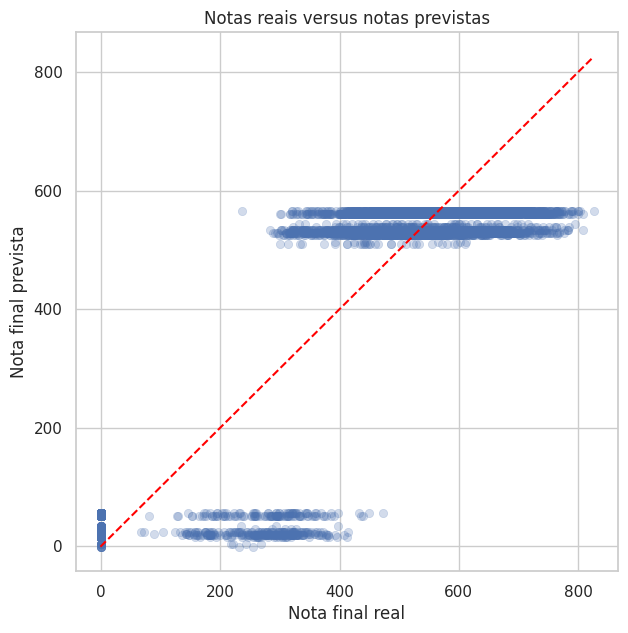

In [ ]:
# ============================================================
# Etapa Mineração - Valores reais versus previstos
# ============================================================

amostra_grafico = pd.DataFrame({
    "Nota real": y_teste,
    "Nota prevista": y_pred
}).sample(n=min(10000, len(y_teste)), random_state=42)

plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=amostra_grafico,
    x="Nota real",
    y="Nota prevista",
    alpha=0.25,
    edgecolor=None
)

limite_min = min(amostra_grafico["Nota real"].min(), amostra_grafico["Nota prevista"].min())
limite_max = max(amostra_grafico["Nota real"].max(), amostra_grafico["Nota prevista"].max())
plt.plot([limite_min, limite_max], [limite_min, limite_max], color="red", linestyle="--")

plt.title("Notas reais versus notas previstas")
plt.xlabel("Nota final real")
plt.ylabel("Nota final prevista")
plt.show()


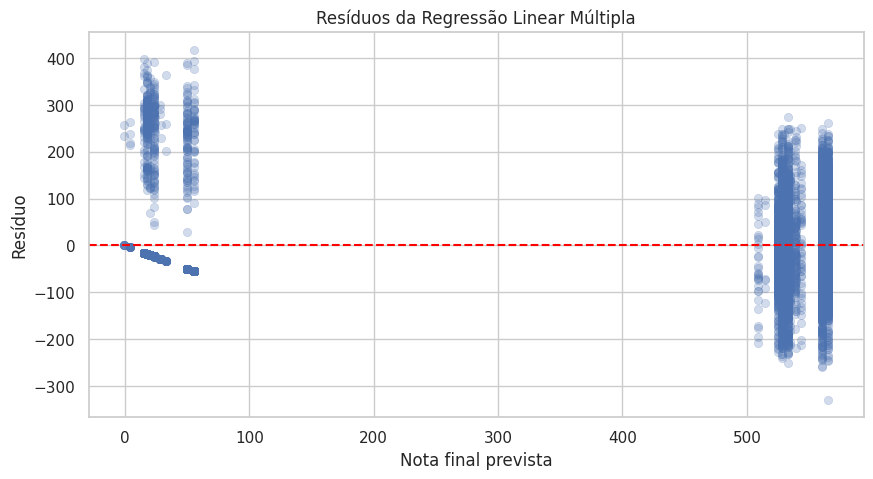

In [ ]:
# ============================================================
# Etapa Mineração - Análise dos resíduos
# ============================================================

df_residuos = pd.DataFrame({
    "Nota prevista": y_pred,
    "Residuo": residuos
}).sample(n=min(10000, len(y_teste)), random_state=42)

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_residuos,
    x="Nota prevista",
    y="Residuo",
    alpha=0.25,
    edgecolor=None
)
plt.axhline(0, color="red", linestyle="--")

plt.title("Resíduos da Regressão Linear Múltipla")
plt.xlabel("Nota final prevista")
plt.ylabel("Resíduo")
plt.show()


In [ ]:
# ============================================================
# Etapa Mineração - Coeficientes da Regressão Linear Múltipla
# ============================================================

coeficientes_regressao = pd.DataFrame({
    "Variavel": X_treino.columns,
    "Coeficiente": modelo_regressao_linear.coef_
}).sort_values(by="Coeficiente", ascending=False)

coeficientes_regressao["Coeficiente_abs"] = coeficientes_regressao["Coeficiente"].abs()
coeficientes_regressao_importancia = coeficientes_regressao.sort_values(
    by="Coeficiente_abs",
    ascending=False
)

print("="*70)
print("COEFICIENTES — REGRESSÃO LINEAR MÚLTIPLA")
print("="*70)

print(f"\nIntercepto: {modelo_regressao_linear.intercept_:.4f}")

print("\nCoeficientes positivos:")
display(coeficientes_regressao.head(20).drop(columns="Coeficiente_abs"))

print("\nCoeficientes negativos:")
display(coeficientes_regressao.tail(20).drop(columns="Coeficiente_abs"))


COEFICIENTES — REGRESSÃO LINEAR MÚLTIPLA

Intercepto: 24.2757

Coeficientes positivos:


,Variavel,Coeficiente
0,PRESENTE,510.151909
1,raca_1,26.010322
6,sexo_M,5.000025
4,raca_4,4.016754
3,raca_3,-6.131615
2,raca_2,-9.265469
5,raca_5,-25.232307



Coeficientes negativos:


,Variavel,Coeficiente
0,PRESENTE,510.151909
1,raca_1,26.010322
6,sexo_M,5.000025
4,raca_4,4.016754
3,raca_3,-6.131615
2,raca_2,-9.265469
5,raca_5,-25.232307


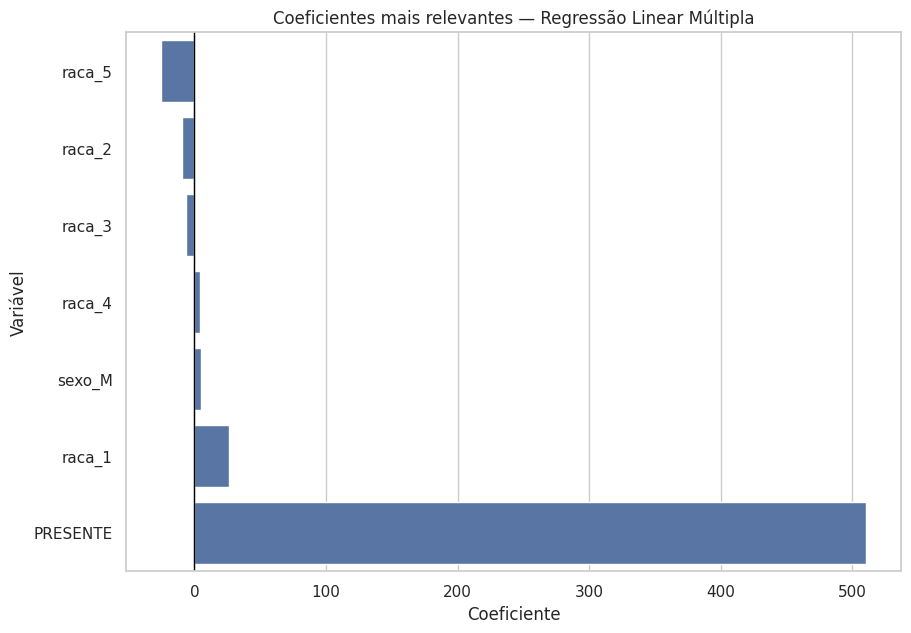

In [ ]:
# ============================================================
# Etapa Mineração - Gráfico dos coeficientes mais relevantes
# ============================================================

top_coeficientes = coeficientes_regressao_importancia.head(20).copy()
top_coeficientes = top_coeficientes.sort_values(by="Coeficiente")

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_coeficientes,
    x="Coeficiente",
    y="Variavel"
)
plt.axvline(0, color="black", linewidth=1)

plt.title("Coeficientes mais relevantes — Regressão Linear Múltipla")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.show()


In [ ]:
# ============================================================
# Etapa Mineração - Salvamento dos resultados e metadados
# ============================================================

PASTA_MINERACAO = os.path.join("/content/drive/MyDrive/data_major", "mineracao")
os.makedirs(PASTA_MINERACAO, exist_ok=True)

CAMINHO_RESULTADOS_MODELO = os.path.join(PASTA_MINERACAO, "resultados_regressao_linear_multipla.csv")
CAMINHO_COEFICIENTES_REGRESSAO = os.path.join(PASTA_MINERACAO, "coeficientes_regressao_linear_multipla.csv")
CAMINHO_METADADOS_MINERACAO = os.path.join(PASTA_MINERACAO, "mineracao_metadata.json")

resultados_modelo.to_csv(CAMINHO_RESULTADOS_MODELO, index=False)
coeficientes_regressao.drop(columns="Coeficiente_abs").to_csv(CAMINHO_COEFICIENTES_REGRESSAO, index=False)

metadados_mineracao = {
    "projeto": "data major - ENEM 2022",
    "tema": "Regressão linear múltipla para nota final",
    "etapa": "Mineração",
    "responsavel": "Matheus de Paula Machado Turturro",
    "data_execucao": datetime.now().isoformat(),
    "entrada": {
        "arquivo": CAMINHO_PARQUET_MODELO,
        "linhas_carregadas": int(df_mineracao.shape[0]),
        "colunas_carregadas": int(df_mineracao.shape[1]),
        "linhas_usadas_modelo": int(len(base_modelo))
    },
    "variavel_alvo": "NOTA_FINAL",
    "colunas_notas_usadas": colunas_notas,
    "criterio_presenca": criterio_presenca,
    "variaveis_explicativas": colunas_modelo,
    "colunas_escola_removidas": colunas_escola_removidas,
    "modelo_utilizado": "Regressão Linear Múltipla",
    "metricas_avaliacao": ["MAE", "RMSE", "R2"],
    "resultados": {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "intercepto": float(modelo_regressao_linear.intercept_)
    },
    "observacoes": [
        "A mineração foi limitada às variáveis solicitadas: presença, raça dummyzada e sexo dummyzado.",
        "A variável de escola foi excluída explicitamente do modelo.",
        "A presença foi agregada em variável binária: presente ou ausente.",
        "A nota final foi calculada como média das notas disponíveis."
    ]
}

with open(CAMINHO_METADADOS_MINERACAO, "w", encoding="utf-8") as f:
    json.dump(metadados_mineracao, f, ensure_ascii=False, indent=4)

print("Resultados da mineração salvos com sucesso.")
print(f"\nResultados do modelo: {CAMINHO_RESULTADOS_MODELO}")
print(f"Coeficientes: {CAMINHO_COEFICIENTES_REGRESSAO}")
print(f"Metadados da Mineração: {CAMINHO_METADADOS_MINERACAO}")


Resultados da mineração salvos com sucesso.

Resultados do modelo: /content/drive/MyDrive/data_major/mineracao/resultados_regressao_linear_multipla.csv
Coeficientes: /content/drive/MyDrive/data_major/mineracao/coeficientes_regressao_linear_multipla.csv
Metadados da Mineração: /content/drive/MyDrive/data_major/mineracao/mineracao_metadata.json


In [ ]:
# ============================================================
# Etapa Mineração - Relatório final
# ============================================================

print("\n" + "="*70)
print("RELATÓRIO FINAL — ETAPA MINERAÇÃO")
print("="*70)

print(f"\nProjeto  : data major — ENEM 2022")
print(f"Tema     : Regressão linear múltipla para nota final")
print(f"Concluído: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")

print("\nPipeline executado:")
print("Dataset de modelagem carregado")
print("NOTA_FINAL calculada como variável-alvo")
print("Presença agregada em presente/ausente")
print("Raça dummyzada incluída")
print("Sexo dummyzado incluído")
print("Variáveis de escola removidas")
print("Divisão treino/teste realizada")
print("Regressão Linear Múltipla treinada e avaliada")
print("Coeficientes analisados")
print("Resultados e metadados salvos")

print("\nResumo do modelo:")
display(resultados_modelo_exibicao)

print("\nArtefatos gerados:")
print(f"- {CAMINHO_RESULTADOS_MODELO}")
print(f"- {CAMINHO_COEFICIENTES_REGRESSAO}")
print(f"- {CAMINHO_METADADOS_MINERACAO}")

print("\nEtapa Mineração concluída.")
print("="*70)



RELATÓRIO FINAL — ETAPA MINERAÇÃO

Projeto  : data major — ENEM 2022
Tema     : Regressão linear múltipla para nota final
Concluído: 16/06/2026 21:15:53

Pipeline executado:
Dataset de modelagem carregado
NOTA_FINAL calculada como variável-alvo
Presença agregada em presente/ausente
Raça dummyzada incluída
Sexo dummyzado incluído
Variáveis de escola removidas
Divisão treino/teste realizada
Regressão Linear Múltipla treinada e avaliada
Coeficientes analisados
Resultados e metadados salvos

Resumo do modelo:


,Modelo,MAE,RMSE,R2,Intercepto,Tempo treino (s),Qtde variáveis,Linhas usadas
0,Regressão Linear Múltipla,63.7064,87.8273,0.8863,24.2757,0.4345,7,2963373



Artefatos gerados:
- /content/drive/MyDrive/data_major/mineracao/resultados_regressao_linear_multipla.csv
- /content/drive/MyDrive/data_major/mineracao/coeficientes_regressao_linear_multipla.csv
- /content/drive/MyDrive/data_major/mineracao/mineracao_metadata.json

Etapa Mineração concluída.
